In [1]:
savepathIMG = "../Images/"
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

c:\Users\Dell_i5\Documents\GitHub\BCI_Project\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


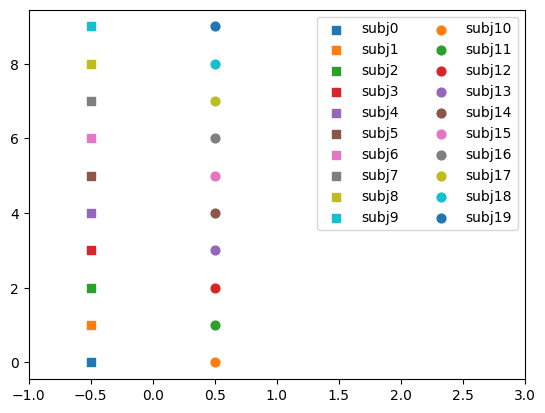

In [49]:
import matplotlib.pyplot as plt
markes=["s","o"]
size=40

for subject in range(20):

    shifcolor=1 if subject>=10 else 0
    color=f"C{subject+shifcolor}"

    plt.scatter([subject//10 - 0.5],[subject%10], marker=markes[subject//10],s=size,color=color,label=f"subj{subject}")#facecolors='none',edgecolors=color
    plt.xlim(-1,3)
    plt.legend(ncol=2)

# Before 12/2025, selection MyCriteria on band 4 - 30 Hz

## Personalized freqs vs Standard freqs

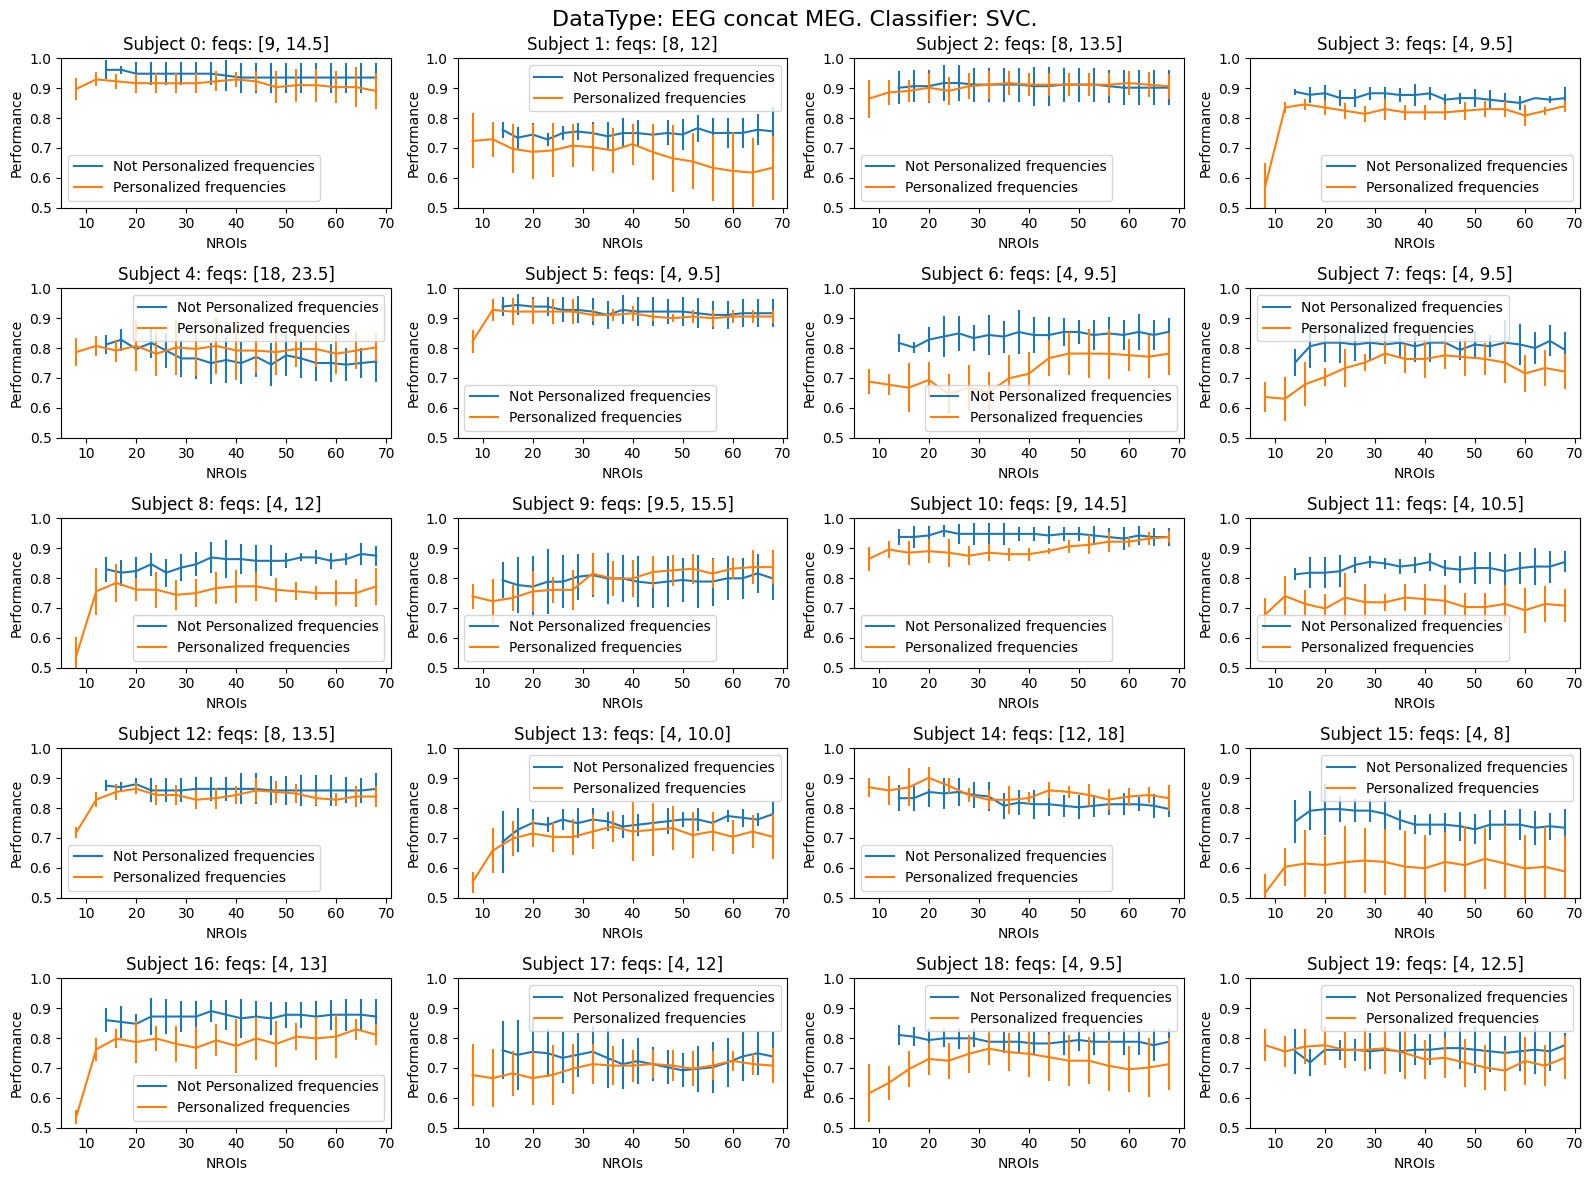

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"SVC"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":False})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Not Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":True})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}: feqs: {freq_personalized[f'subject_{subject}']}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

## Different Classifiers - Fixed Datatypes

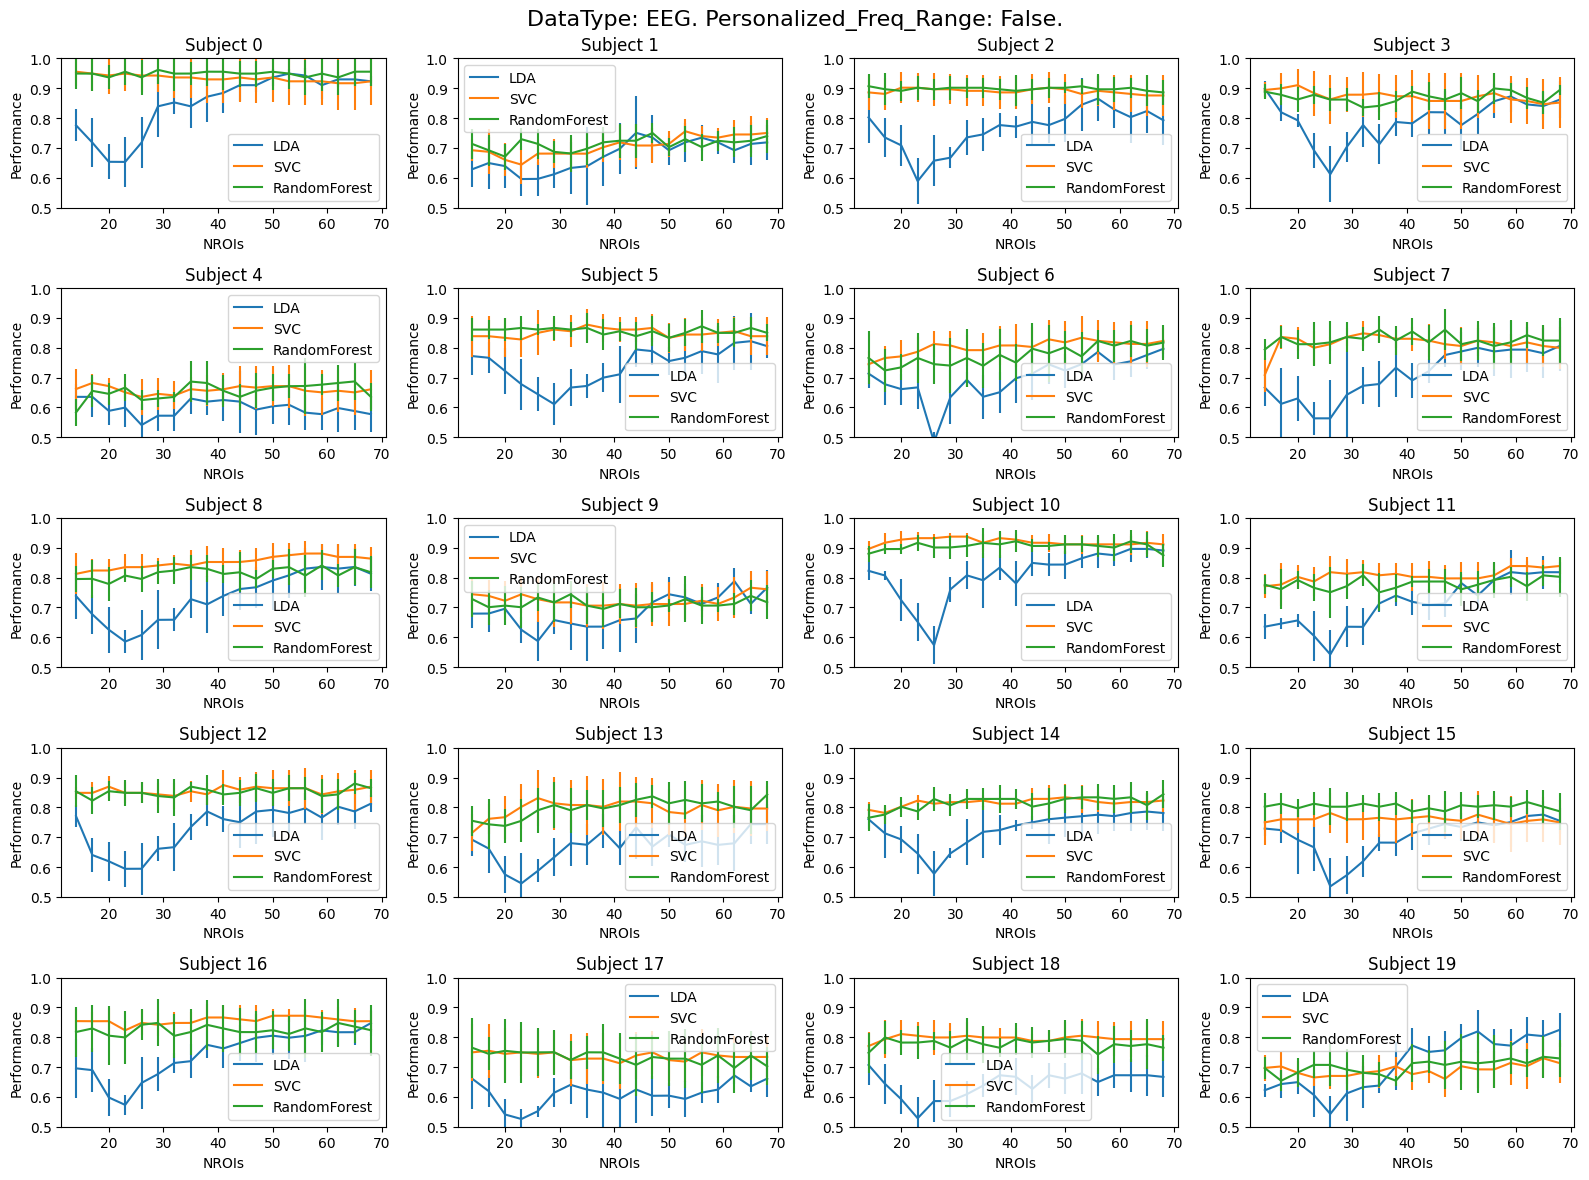

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG","Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"LDA"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="LDA")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"SVC"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="SVC")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"RandomForest"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="RandomForest")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_notPersonalised_vs_Classifier.png")
plt.show()

## Different Datatypes - Fixed Classifiers

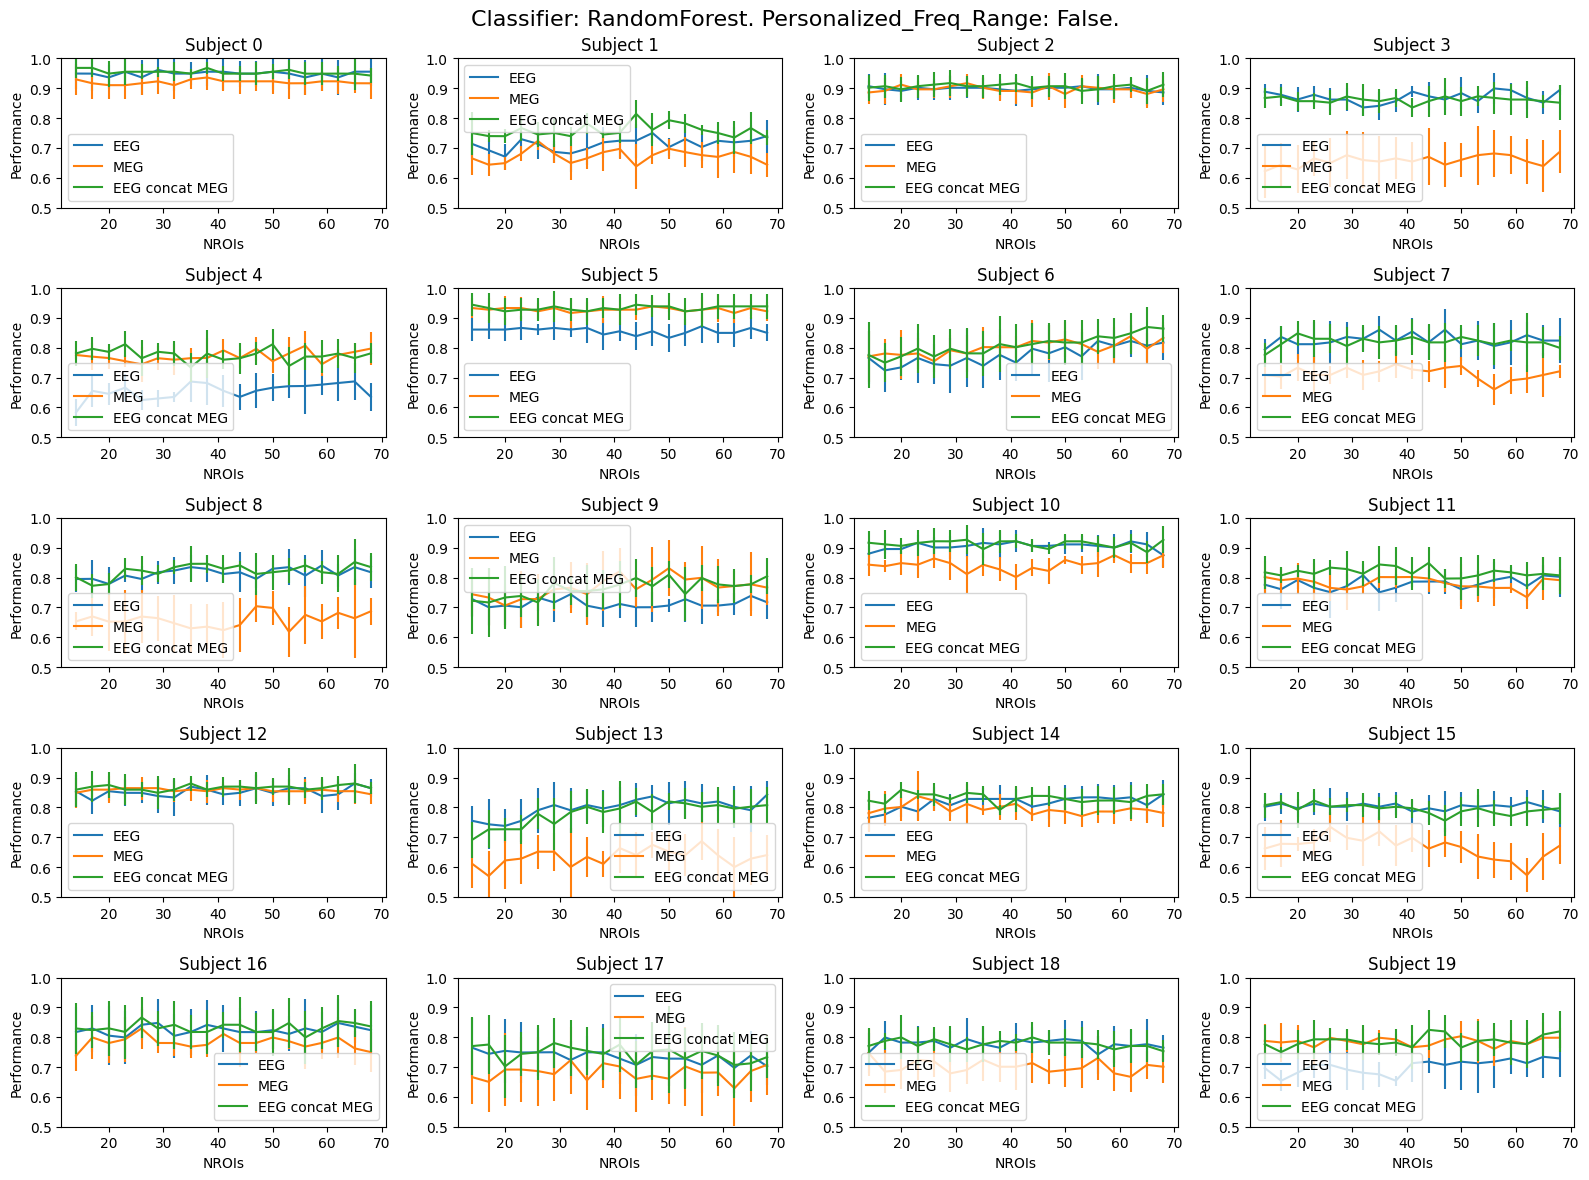

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"RandomForest","Personalized_Freq_Range":False,}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG", "Region Selection":"-"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"MEG", "Region Selection":"-"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG concat MEG", "Region Selection":"ROIs: EEG then MEG"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG concat MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_concat_MEG_vs_EEG_vs_MEG_SVM.png")
plt.show()

In [3]:
rows

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
2641,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",14.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.684...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2642,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",17.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7368421052631579, 0.7368421052631579, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2643,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",20.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2644,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",23.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.868421052631579, 0.7368421052631579, 0.7105...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2645,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",26.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.763...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2646,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",29.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2647,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",32.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.8421052631578947, 0.7368421052631579, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2648,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",35.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.8157894736842105, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2649,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",38.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.710...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2650,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",41.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.710...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False


## Only Mean - Only Max

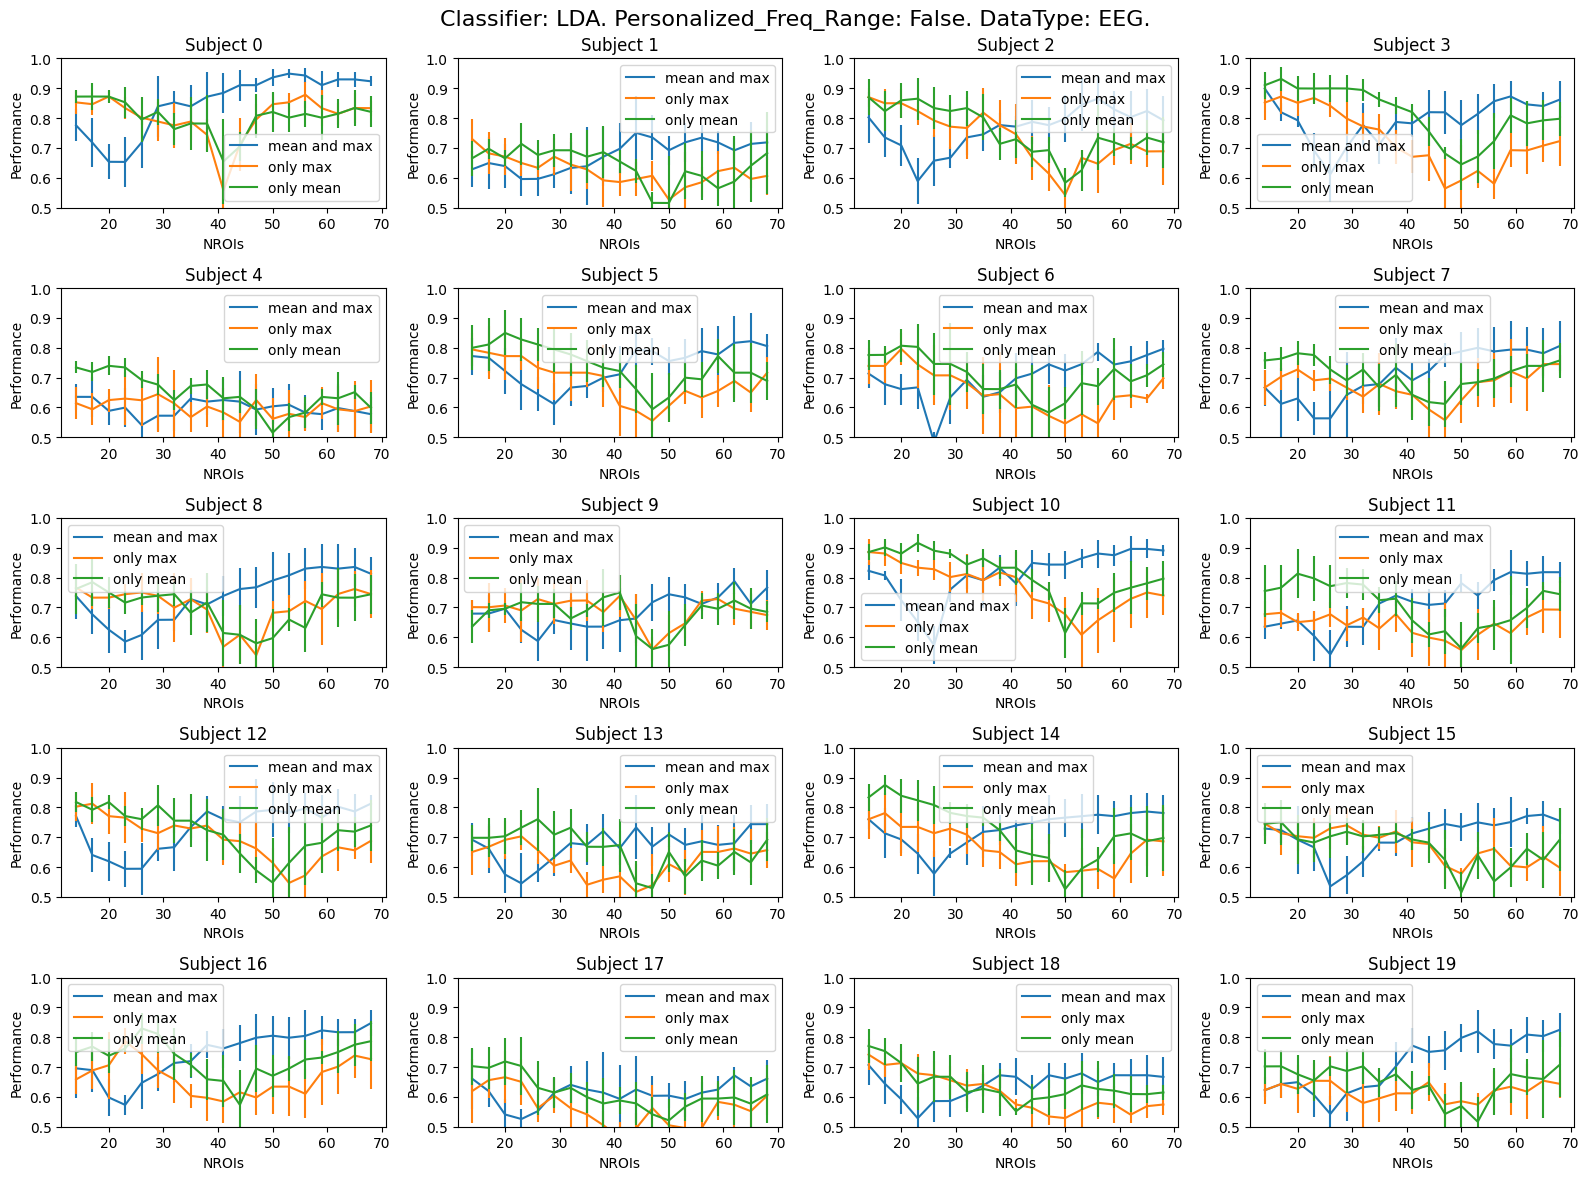

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
PerData2 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_ony1Feature.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"LDA","Personalized_Freq_Range":False,"DataType":"EEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values 
    ax.plot(nrois, allperf.mean(axis=1),label="mean and max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Region Selection":"Only max"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="only max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Region Selection":"Only mean"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="only mean")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
savepathIMG = "../Images/"
plt.savefig(savepathIMG+"Perf_max_mean_EEF_LDA.png")
plt.show()

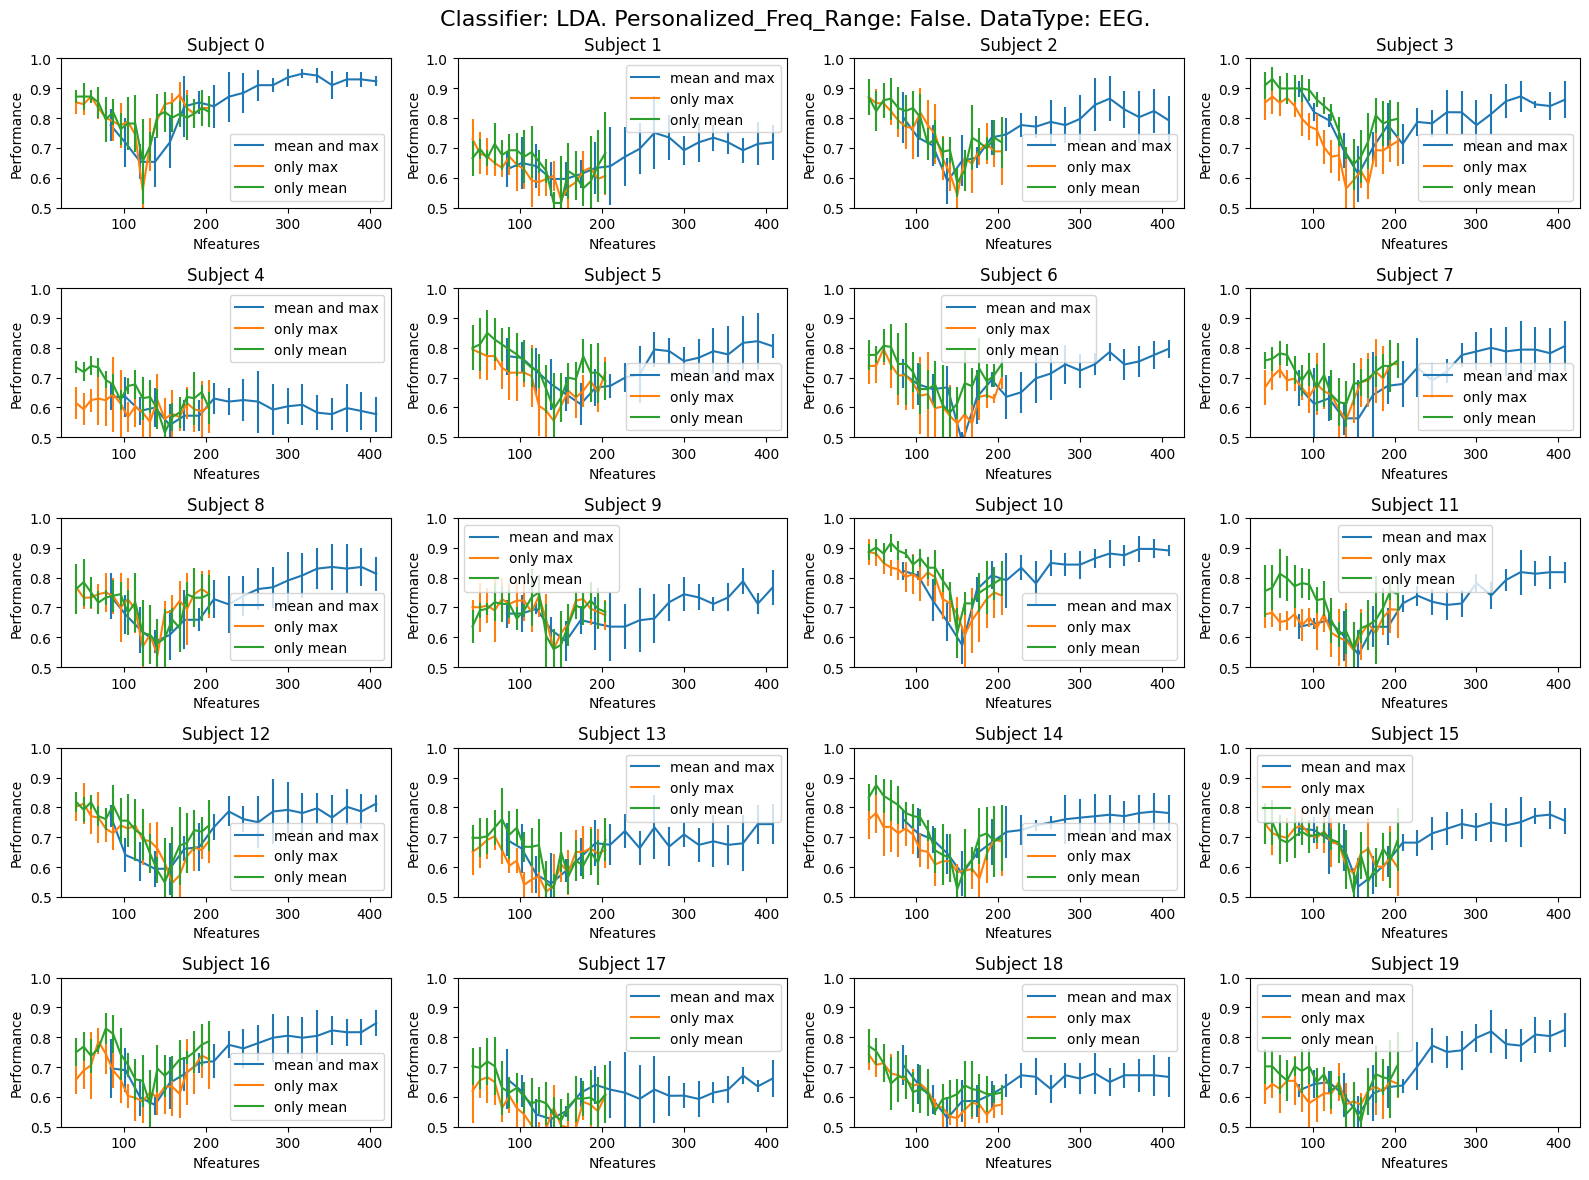

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
PerData2 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_ony1Feature.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"LDA","Personalized_Freq_Range":False,"DataType":"EEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values * 6
    ax.plot(nrois, allperf.mean(axis=1),label="mean and max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Region Selection":"Only max"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values * 3
    ax.plot(nrois, allperf.mean(axis=1),label="only max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Region Selection":"Only mean"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values * 3
    ax.plot(nrois, allperf.mean(axis=1),label="only mean")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("Nfeatures")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
savepathIMG = "../Images/"
plt.savefig(savepathIMG+"Perf_max_mean_EEF_LDA_xaxis_Nfeatures.png")
plt.show()

## Regions' Investigation

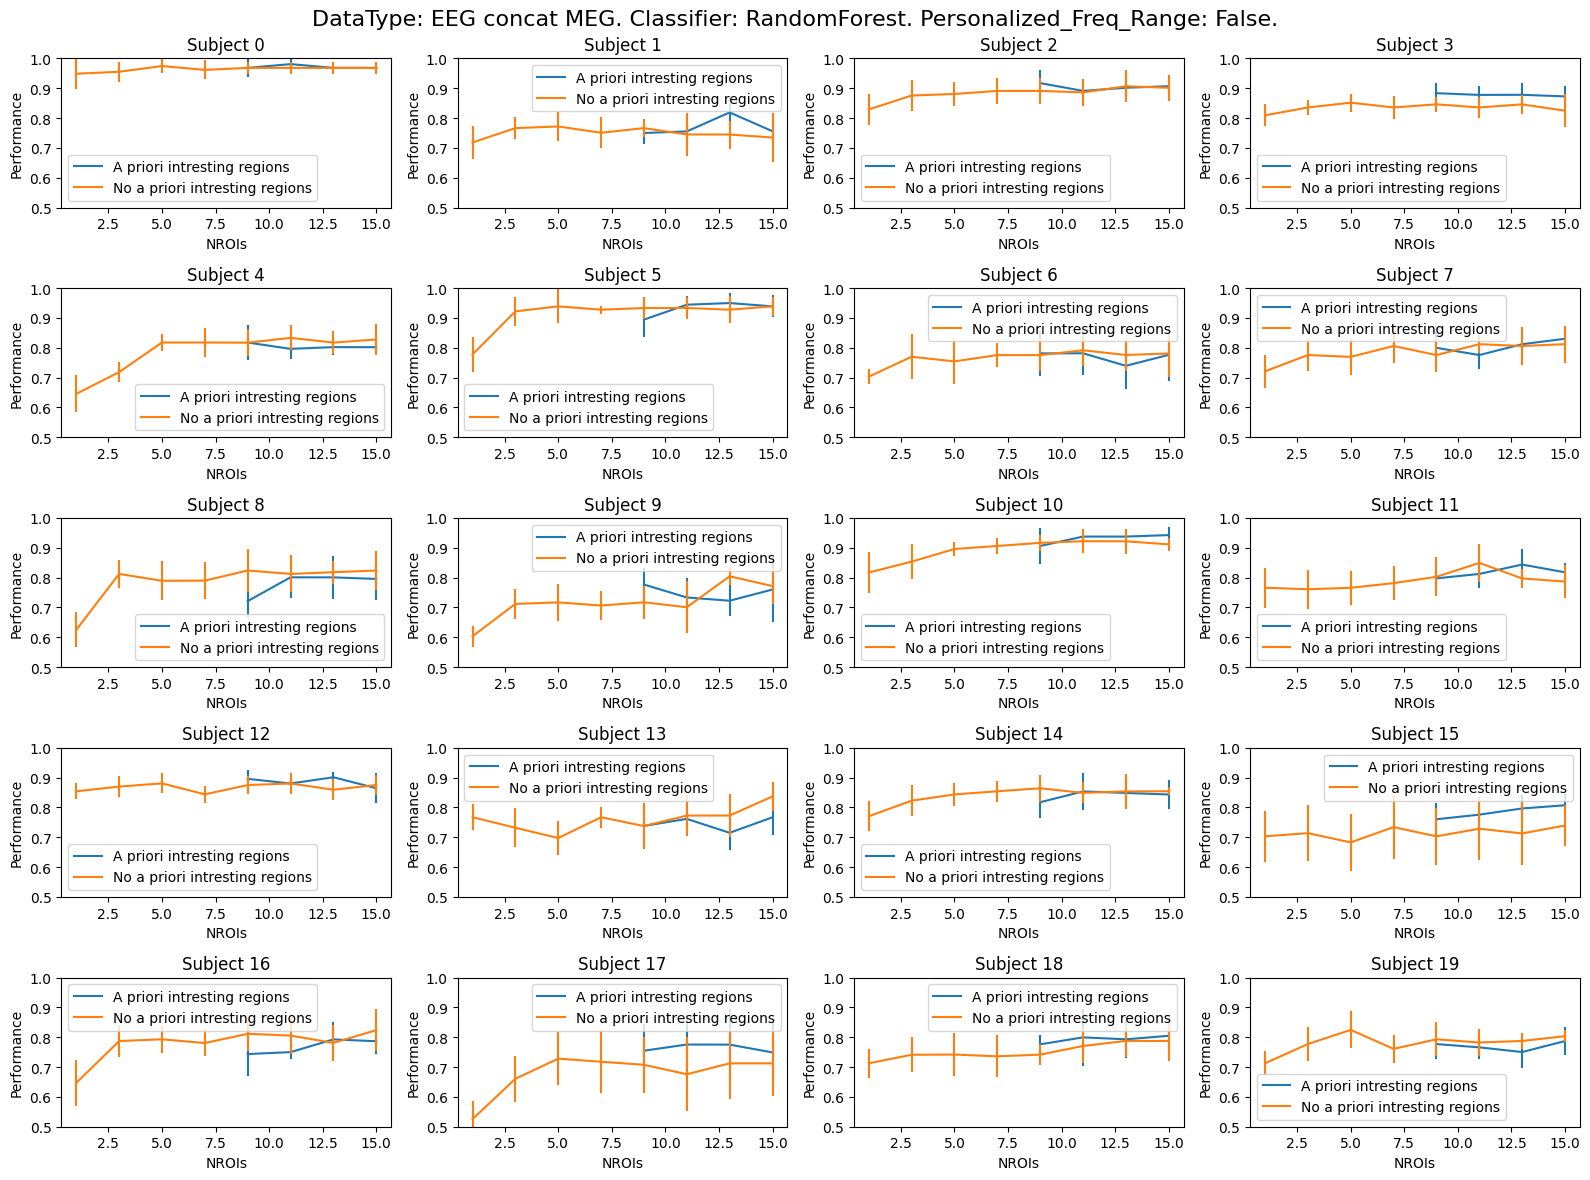

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_Important_regions_all.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"RandomForest", "Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Region Selection":"Yes Important Regions"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="A priori intresting regions")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Region Selection":"No Interesting Regions"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="No a priori intresting regions")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

## Single graph with every subject vs Classifier-DataType

### regions old method - Interesting + selected

In [ ]:
pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
0,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",14.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.78125, 0.6774193548387096, 0.83870967741935...",PowerSpectra - MeanMax band,-,2025-11-20,False
1,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",17.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.8125, 0.6774193548387096, 0.580645161290322...",PowerSpectra - MeanMax band,-,2025-11-20,False
2,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",20.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.75, 0.5806451612903226, 0.6129032258064516,...",PowerSpectra - MeanMax band,-,2025-11-20,False
3,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",23.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.8125, 0.6451612903225806, 0.612903225806451...",PowerSpectra - MeanMax band,-,2025-11-20,False
4,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",26.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.75, 0.6774193548387096, 0.8387096774193549,...",PowerSpectra - MeanMax band,-,2025-11-20,False
...,...,...,...,...,...,...,...,...,...,...,...
4695,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",52.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.8157894736842105, 0.7631578947368421, 0.684...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False
4696,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",56.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.8421052631578947, 0.7894736842105263, 0.763...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False
4697,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",60.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.7894736842105263, 0.7105263157894737, 0.710...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False
4698,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",64.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.8947368421052632, 0.7105263157894737, 0.684...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False


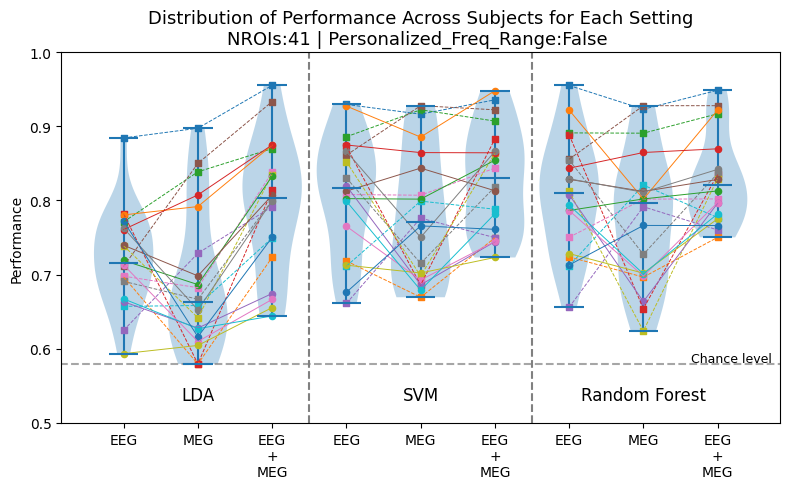

In [ ]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
VisualizigNROIs=41
dict_fixed_selection = {"NROIs":VisualizigNROIs,  "Personalized_Freq_Range":False}
classifiers=["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes=["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]
dict_per_setting = {"DataType":Datatypes, "Classifier":classifiers}
x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]
divisioni = [0,3,6,9]
textes = ["LDA", "SVM", "Random Forest"]
textes_x_positions = [.19, .5, .81]
savepathIMG+"Performance_vs_Setting_41_ROIs.png"


plot_violin_all_subj(PerData,  9,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, divisioni,
                  track_subjects=True,  savepath=False)


### Only interesting regions

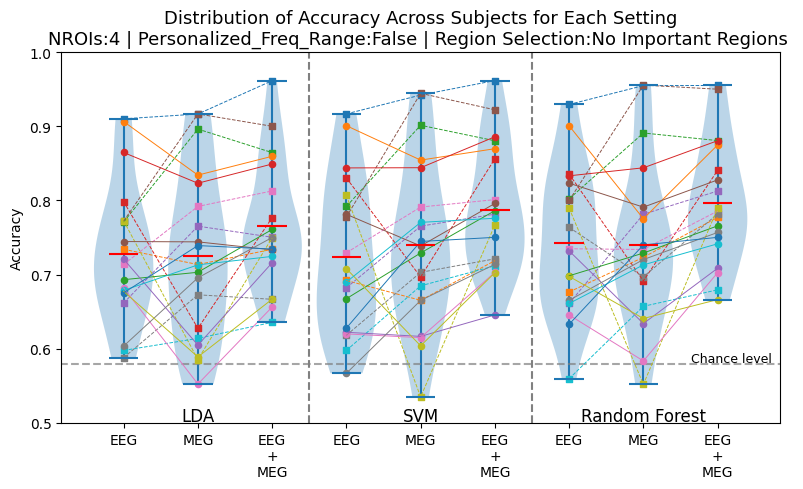

In [2]:
import pandas as pd

# keys to be selected: 
# DataType,         EEG - MEG - concat (Concat da fare)
# Classifier,       LDA - SVC - Random
# NROIs,            4lh - 4rh - 4lh+4rh - 4free - 8free 
        # Yes important regions - left
        # Yes important regions - right
        # Yes important regions - all
        # No important regions 
# subject, 
# Personalized_Freq_Range

reg_sel="No Important Regions"# TODO change here 
VisualizigNROIs=4
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_Important_regions.pkl")
dict_fixed_selection = {"NROIs":VisualizigNROIs,  "Personalized_Freq_Range":False, "Region Selection":reg_sel}
classifiers=["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes=["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]
x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]
dict_per_setting = {"DataType":Datatypes, "Classifier":classifiers}
textes = ["\nLDA", "\nSVM", "\nRandom Forest"]
textes_x_positions = [.19, .5, .81]
divisioni  = [0,3,6,9]
savepathIMG+"Performance_vs_Setting_no_important_4.png"
plot_violin_all_subj(PerData,  9,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, divisioni,
                  track_subjects=True,  savepath=False)



In [10]:
set(PerData.Comments)

{'No Interesting Regions',
 'No important regions',
 'Only one region',
 'Yes Important Regions',
 'Yes important regions - all',
 'Yes important regions - left',
 'Yes important regions - right'}

## How many times i select a ROI? - Among subjects - Plot on the brain

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
colors = {"EEG":"green","MEG":"blue"}


for DataType in ["EEG",]:
    for NROIs in [17]:#[14,29,41]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        

        dict_fixed_selection = {"NROIs":NROIs,"Personalized_Freq_Range":False, "Classifier":"SVC", "DataType":DataType}
        PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
        rows = select_rows(PerData, dict_fixed_selection)

        allRois=[]
        for i in rows["ROIs"].values:
            allRois+=i

        for roi in allRois:
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0) + 1
        for roi in range(68):
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0)

        crs = [cmap(_/20) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs{NROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f"{DataType}_NROIs{NROIs}",
            position="upper_left",
            font_size=12,
            color="black",
        )

        my_brain.add_text(0,0.5,"fja")

        #my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs{NROIs}.png")



Using pyvistaqt 3d backend.
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
colors = {"EEG":"green","MEG":"blue"}

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_Important_regions.pkl")

for DataType in ["EEG","MEG"]:
    for NROIs in [4,8]:#[14,29,41]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        

        dict_fixed_selection = {"NROIs":NROIs,"Personalized_Freq_Range":False, "Classifier":"SVC", "DataType":DataType,"Region Selection":"No important regions"}
        
        rows = select_rows(PerData, dict_fixed_selection)

        allRois=[]
        for i in rows["ROIs"].values:
            allRois+=i

        for roi in allRois:
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0) + 1
        for roi in range(68):
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0)

        crs = [cmap(_/7) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs_{NROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f"{DataType}_NROIs_{NROIs}",
            position="upper_left",
            font_size=12,
            color="black",
        )

        #my_brain.add_text(0,0.5,"fja")
        print(DataType, NROIs, max(how_many_times.values()))
        my_brain.save_image(savepathIMG+f"Brain_no_important_regions_{DataType}_NROIs_{NROIs}.png")



Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
EEG 4 5
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
EEG 8 7
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
MEG 4 4
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/m

In [11]:
sum(how_many_times.values())

160

In [ ]:
rows

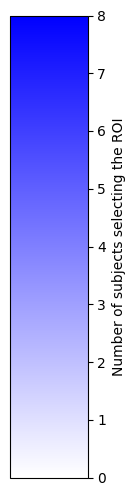

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase

cmap = LinearSegmentedColormap.from_list("white_to_green", ["white", "blue"])
norm = Normalize(vmin=0, vmax=8)
fig, ax = plt.subplots(figsize=(1, 6))  # tall figure for vertical colorbar
ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', label='Number of subjects selecting the ROI')
#plt.show()
plt.savefig(f"{savepathIMG}colorbar_white_to_blue_max8.png", dpi=300, bbox_inches='tight')


## Frequencies selection

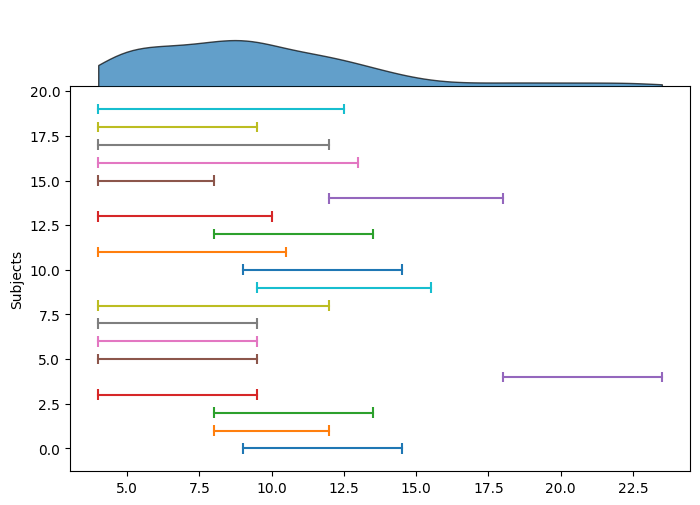

In [31]:
import matplotlib.pyplot as plt
import numpy as np

freq_personalized = {
    "subject_0":[9,14.5], "subject_1":[8,12], "subject_2":[8,13.5],
    "subject_3":[4,9.5], "subject_4":[18,23.5], "subject_5":[4,9.5],
    "subject_6":[4,9.5], "subject_7":[4,9.5], "subject_8":[4,12],
    "subject_9":[9.5,15.5], "subject_10":[9,14.5], "subject_11":[4,10.5],
    "subject_12":[8,13.5], "subject_13":[4,10.], "subject_14":[12,18],
    "subject_15":[4,8], "subject_16":[4,13], "subject_17":[4,12],
    "subject_18":[4,9.5], "subject_19":[4,12.5],
}

# Flatten all frequency ranges for cumulative violin
all_freqs = []
for subj in freq_personalized.values():
    all_freqs.extend(np.linspace(subj[0], subj[1], 50))
all_freqs = np.array(all_freqs)

fig, ax_main = plt.subplots(1,1, figsize=(8,5))
# Main plot: individual subjects
for subject in range(20):
    ax_main.plot(freq_personalized[f"subject_{subject}"], [subject,subject], color=f"C{subject}")
    ax_main.vlines(freq_personalized[f"subject_{subject}"], subject-0.3, subject+0.3, color=f"C{subject}")
ax_main.set_ylabel("Subjects")



# Create twin axis sharing x-axis but at the bottom
ax_violin = ax_main.inset_axes([0,1, 1, 0.2])  # x0, y0, width, height in axis fraction

viol = ax_violin.violinplot(all_freqs, positions=[0], widths=1.2,
                            showmeans=False, showmedians=False, showextrema=False, vert=False)

for i, body in enumerate(viol['bodies']):
    verts = body.get_paths()[0].vertices
    if i == 0:
        # one half
        verts[:,1] = np.clip(verts[:,1], 0, None)
        body.set_facecolor('C0')
    else:
        # other  half
        verts[:,1] = np.clip(verts[:,1], None, 0)
        body.set_facecolor('C0')
    body.set_edgecolor('black')
    body.set_alpha(0.7)

ax_violin.set_yticks([])
ax_violin.set_xticks([])
ax_violin.set_ylim(0,1)
# ax_violin.set_xlabel("Frequencies (Hz)")
ax_violin.set_xlim(ax_main.get_xlim())
ax_violin.set_frame_on(False)


plt.show()


# Starting on 12 / 2025 -  Different region selection criteria


## Plot Per Subject

### Vs regions

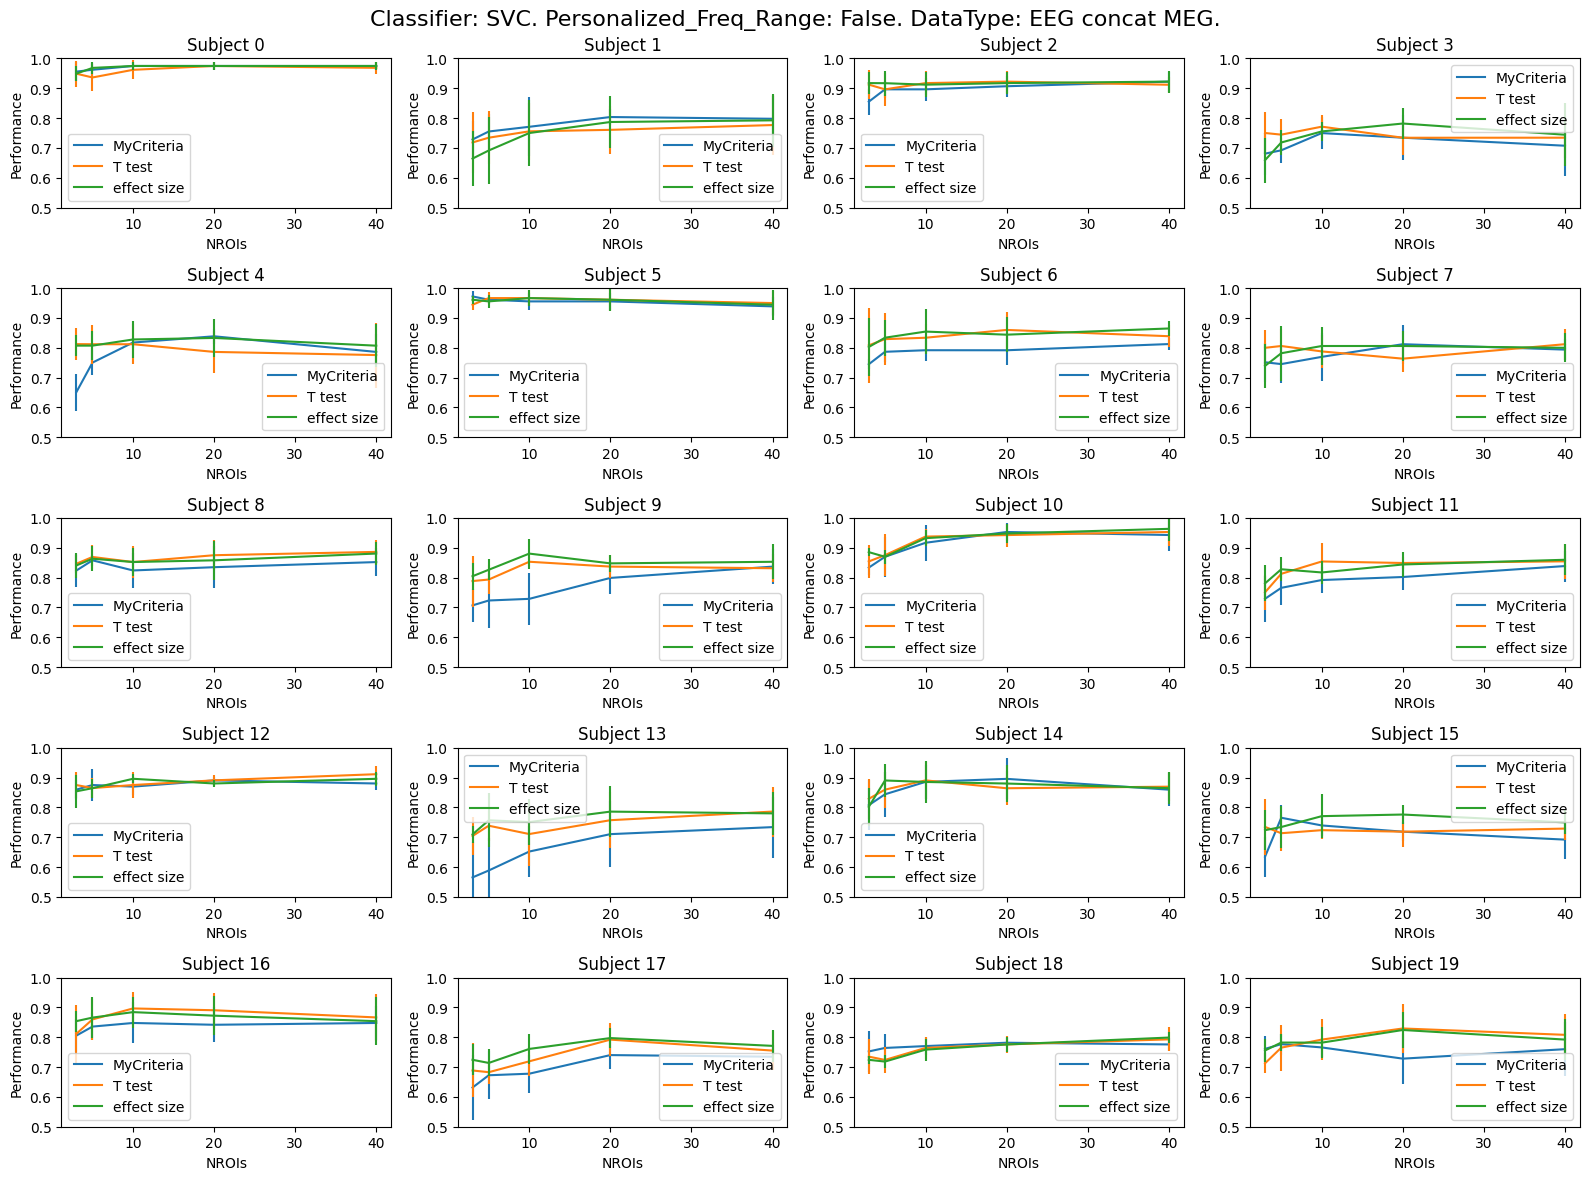

In [ ]:
# Different selections vs ROIs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"SVC","Personalized_Freq_Range":False,"DataType":"EEG concat MEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Region Selection":"MyCriteria selection"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="MyCriteria")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Region Selection": "T test selection mean power alpha beta"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="T test")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Region Selection": "Cohen's d effect size selection"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="effect size")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_concat_MEG_vs_EEG_vs_MEG_SVM.png")
plt.show()

### Only 1 REGION

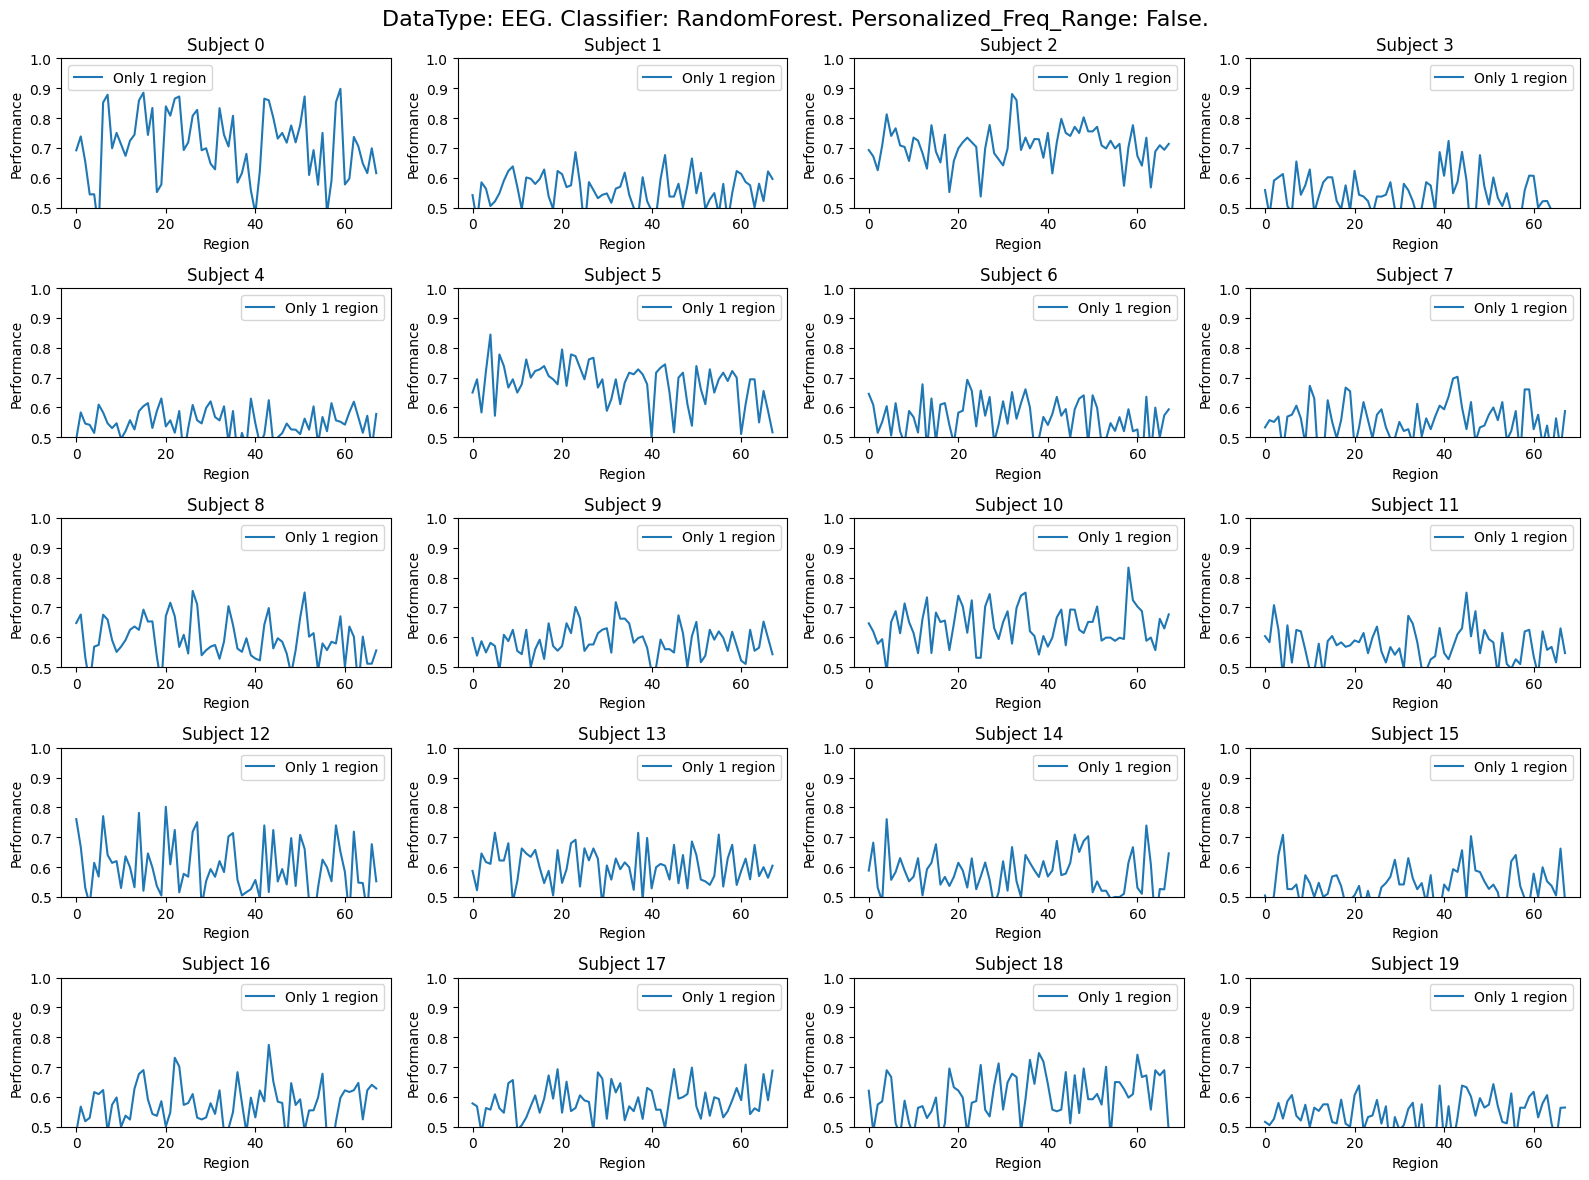

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_on_single_region.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
allallperf = []
dict_fixed_selection = {"DataType":"EEG", "Classifier":"RandomForest", "Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Region Selection":"-"})
    allperf = np.array(list(rows["Accuracy"].values))
    allallperf.append(allperf.mean(axis=1))
    nrois = rows["NROIs"].values
    ax.plot( allperf.mean(axis=1),label="Only 1 region")
    #ax.vlines( [i for i in range(68)], allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1',linestyle="--",alpha=0.8)


    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("Region")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

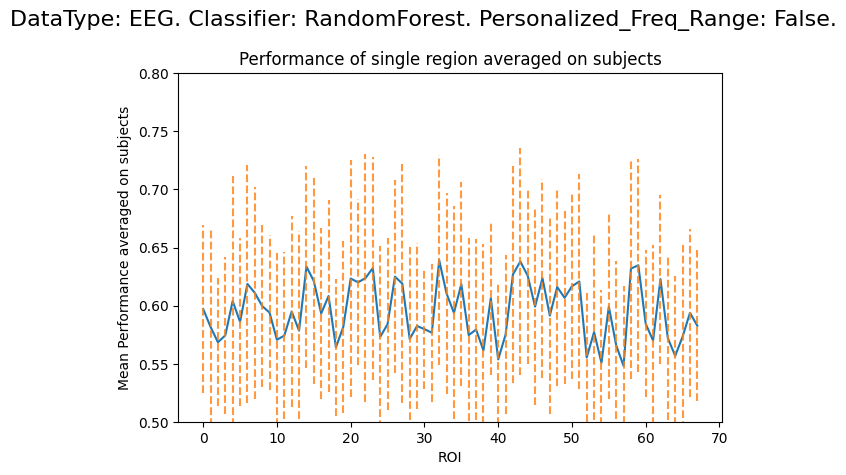

In [33]:
# Averaged over subjects
allallperf=np.array(allallperf)
plt.plot(allallperf.mean(axis=0))
plt.vlines( [i for i in range(68)], allallperf.mean(axis=0)-allallperf.std(axis=0), allallperf.mean(axis=0)+allallperf.std(axis=0), colors='C1',linestyle="--",alpha=0.8)


plt.ylim(0.5, 0.8)
plt.title(f"Performance of single region averaged on subjects")
plt.xlabel("ROI")
plt.ylabel("Mean Performance averaged on subjects")


plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()


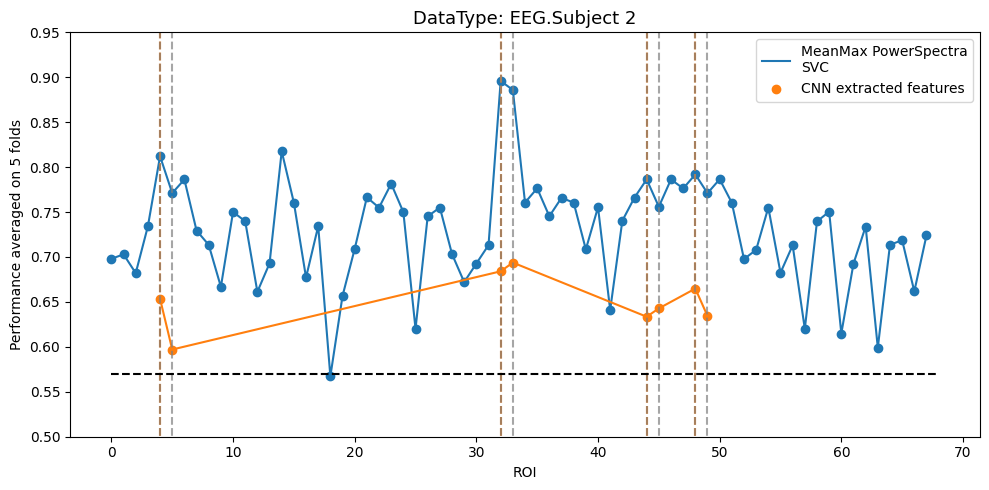

In [40]:
# Comparison with Deep Learning! 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

subject = 2
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_on_single_region.pkl")

#    |
dict_fixed_selection = {"DataType":"EEG"}

# Extract performances
rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Region Selection":"-", "Personalized_Freq_Range":False , "Classifier":"SVC"})
perf_powerSpectra_performances = np.array(list(rows["Accuracy"].values))


fig, axes = plt.subplots(1, 1, figsize=(10, 5))

Classic_Perf = perf_powerSpectra_performances.mean(axis=1)
axes.plot(Classic_Perf, label="MeanMax PowerSpectra\nSVC")
axes.scatter([_ for _ in range(68)],Classic_Perf)

DL_performance = pd.read_pickle("../_Deep_Learning/Models_trained/2026-01-24-11_51_50_First_Try_ok/aggregated_region_performance.pkl")
DL_performance = pd.read_pickle("../_Deep_Learning/Models_trained/2026-01-30-13_17_30_First_Try_good_way_split/aggregated_region_performance.pkl")
DL_performance = pd.read_pickle("../_Deep_Learning/Models_trained/2026-02-02-15_59_15_CNN_1region_region_agnostic_Training_on_Interesting_Regions/aggregated_region_performance.pkl")
x_plot_interesting = DL_performance["region"].values




DL_perf = DL_performance["Accuracy"].apply(np.mean)
axes.plot(x_plot_interesting,DL_perf,)
axes.scatter(x_plot_interesting, DL_perf, label="CNN extracted features")
axes.legend()

axes.vlines(Interesting_regions_left, 0, 1, colors='C1', linestyles='dashed')
axes.vlines(Interesting_regions_left+ Interesting_regions_right, 0, 1, colors='gray', linestyles='dashed', alpha=0.7)
axes.set_ylim(0.5, 0.95)
axes.set_title(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]) + f"Subject 2",fontsize=13)
axes.set_xlabel("ROI")
axes.set_ylabel("Performance averaged on 5 folds")
axes.hlines([0.57],0,68, color="black", linestyles='dashed')
fig.tight_layout()

KeyError: 'Accuracy'

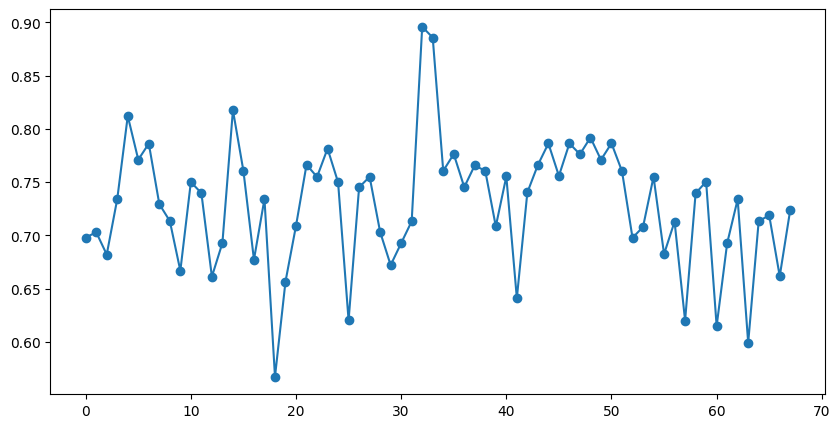

In [3]:
# Comparison with Deep Learning! 

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
region_specific_path = "../_Deep_Learning/Models_trained/2026-02-02-16_14_31_CNN_1region_regionspecific_Interesting_regions/"
pickle_files = [ f for f in os.listdir(region_specific_path) if f.endswith(".pkl") or f.endswith(".pickle")]
df_list = [pd.read_pickle(os.path.join(region_specific_path, f)) for f in pickle_files]
DL_performance = pd.concat(df_list, ignore_index=True)
DL_region_number = DL_performance["region"].tolist()

subject = 2
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_on_single_region.pkl")

#    |
dict_fixed_selection = {"DataType":"EEG"}

# Extract performances
rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Region Selection":"-", "Personalized_Freq_Range":False , "Classifier":"SVC"})
perf_powerSpectra_performances = np.array(list(rows["Accuracy"].values))


fig, axes = plt.subplots(1, 1, figsize=(10, 5))

Classic_Perf = perf_powerSpectra_performances.mean(axis=1)
axes.plot(Classic_Perf, label="MeanMax PowerSpectra\nSVC")
axes.scatter([_ for _ in range(68)],Classic_Perf)



DL_perf = DL_performance["Accuracy"].apply(np.mean)
axes.plot(DL_region_number, DL_perf, label="CNN extracted features")
axes.scatter(DL_region_number, [_ for _ in range(68)],DL_perf)
axes.legend()

axes.vlines(Interesting_regions_left, 0, 1, colors='C1', linestyles='dashed')
axes.vlines(Interesting_regions_left+ Interesting_regions_right, 0, 1, colors='gray', linestyles='dashed', alpha=0.7)
axes.set_ylim(0.5, 0.95)
axes.set_title(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]) + f"Subject 2",fontsize=13)
axes.set_xlabel("ROI")
axes.set_ylabel("Performance averaged on 5 folds")
axes.hlines([0.57],0,68, color="black", linestyles='dashed')
fig.tight_layout()

## Plot All subjects

### Different criteria

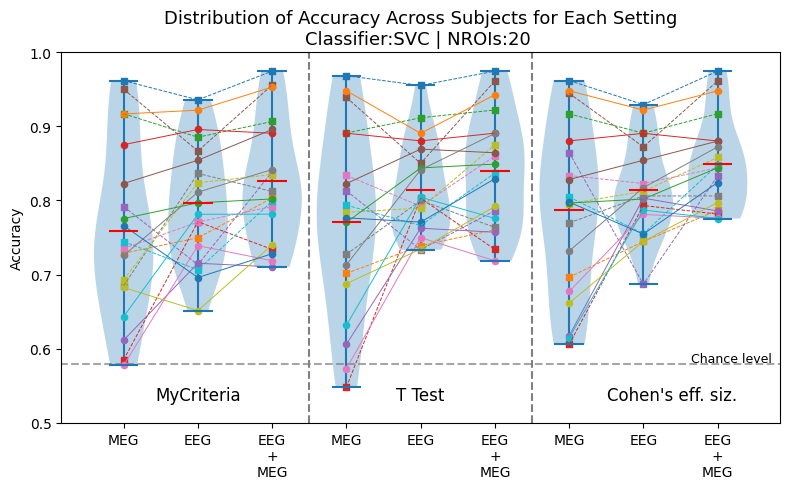

In [3]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
VisualizigNROIs = 20
dict_fixed_selection = {"Classifier":"SVC", "NROIs":VisualizigNROIs}
divisioni = [0,3,6,9]
textes = ["MyCriteria","T Test", "Cohen's eff. siz."]
textes_x_positions = [.19, .5, .85]
Datatypes = ["MEG","EEG","EEG concat MEG"]*3
RegSelections = ["MyCriteria selection"]*3  +  ["T test selection mean power alpha beta"]*3 + ["Cohen's d effect size selection"]*3 #"Cohen's d effect size selection spectra starting from 3s"
x_ticklabels = [_.replace(" concat ","\n+\n") for _ in Datatypes]
dict_per_setting = {"DataType":Datatypes, "Region Selection":RegSelections}
plot_violin_all_subj(PerData,  9,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, 
                  divisioni, hlines_positions=[],
                  track_subjects=True,  savepath=False)


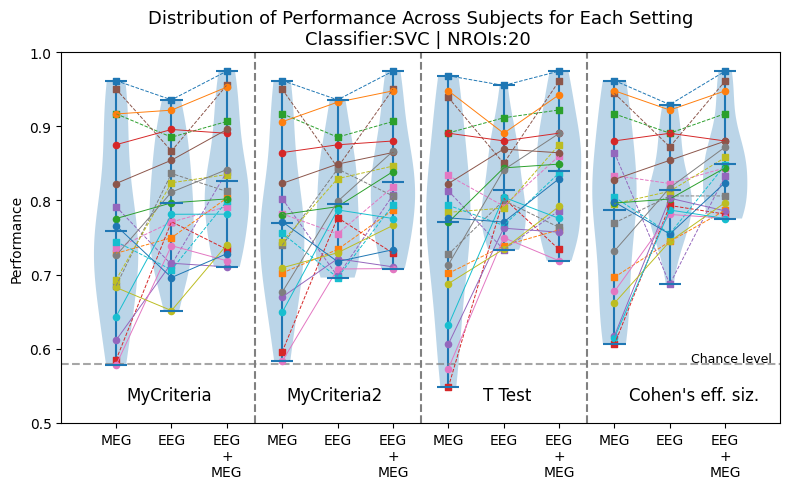

In [ ]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
VisualizigNROIs = 20
dict_fixed_selection = {"Classifier":"SVC", "NROIs":VisualizigNROIs}
divisioni = [0,3,6,9,12]
textes = ["MyCriteria", "MyCriteria2", "T Test", "Cohen's eff. siz."]
textes_x_positions = [.15, .38, .62, .88]
Datatypes = ["MEG","EEG","EEG concat MEG"]*4
RegSelections = ["MyCriteria selection"]*3  + ["MyCriteria2 selection"]*3  + ["T test selection mean power alpha beta"]*3 + ["Cohen's d effect size selection"]*3 #"Cohen's d effect size selection spectra starting from 3s"
x_ticklabels = [_.replace(" concat ","\n+\n") for _ in Datatypes]
dict_per_setting = {"DataType":Datatypes, "Region Selection":RegSelections}
plot_violin_all_subj(PerData,  12,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, 
                  divisioni, hlines_positions=[],
                  track_subjects=True,  savepath=False)


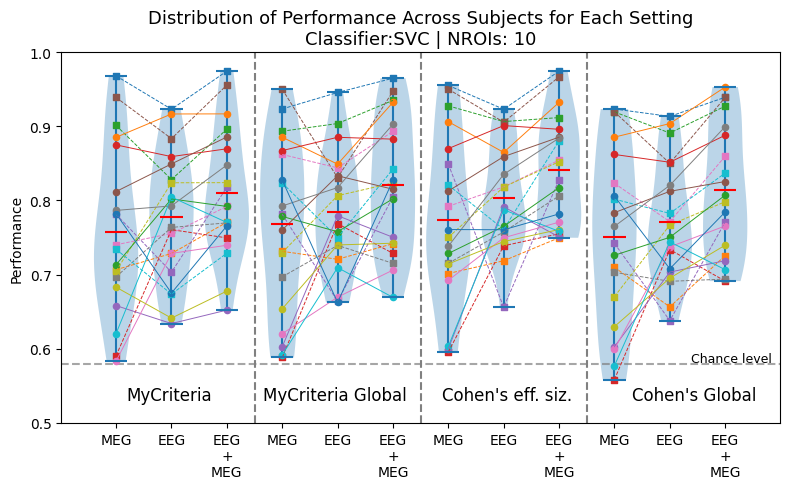

In [ ]:
import pandas as pd
savepathIMG = "../Images/"
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerData10 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl")
PerData["newcol"] = 1
PerData10["newcol"] = 10

combined = pd.concat([PerData, PerData10], ignore_index=True)

VisualizigNROIs = 10
dict_fixed_selection = {"Classifier":"SVC"}

divisioni = [0,3,6,9,12]
Datatypes = ["MEG","EEG","EEG concat MEG"]*4

reg_sel = ["MyCriteria selection"]*3  + ["Global Selection - MyCriteria based"]*3  + ["Cohen's d effect size selection"]*3 +["Global Selection - Cohen based"]*3 #"Cohen's d effect size selection spectra starting from 3s"
newcol = [1]*3 + [10]*3 + [1]*3 + [10]*3 
NROIs = [10]*3 + [11] + [9]*2 + [10]*3 + [10]*3
dict_per_setting = {"DataType":Datatypes, "Region Selection":reg_sel, "NROIs":NROIs, "newcol":newcol}

x_ticklabels = [_.replace(" concat ","\n+\n") for _ in Datatypes]
textes = ["MyCriteria", "MyCriteria Global", "Cohen's eff. siz.",  "Cohen's Global"]
textes_x_positions = [.15, .38, .62, .88]

plot_violin_all_subj(combined,  12,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, 
                  divisioni, hlines_positions=[],
                  track_subjects=True,  savepath=False,
                  additional_title="| NROIs: 10")


### Vs N ROIs

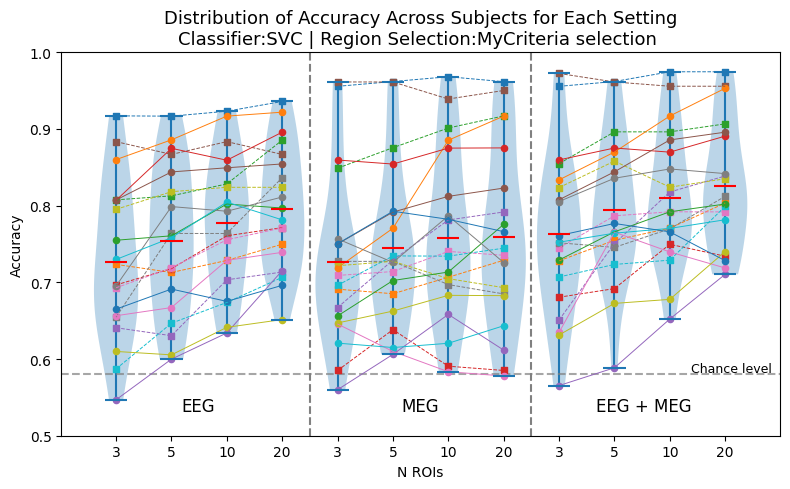

In [33]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
dict_fixed_selection = {"Classifier":"SVC", "Region Selection":"MyCriteria selection"} #
divisioni = [0,4,8,12]
VisualizigNROIs=[3,5,10,20]
Datatypes=["EEG"]* len(VisualizigNROIs) + ["MEG"]* len(VisualizigNROIs) + ["EEG concat MEG"]* len(VisualizigNROIs)
VisualizigNROIs=VisualizigNROIs*3 # 3 is Datatype

dict_per_setting = {"NROIs":VisualizigNROIs, "DataType":Datatypes}
x_ticklabels=[_ for _ in VisualizigNROIs]
textes = ["EEG", "MEG", "EEG + MEG"]
textes_x_positions = [.19,.5,.81]

plot_violin_all_subj(PerData,  12,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions,
                  divisioni, xlabel="N ROIs",
                  track_subjects=True,  savepath=False)


### 10 k-folds

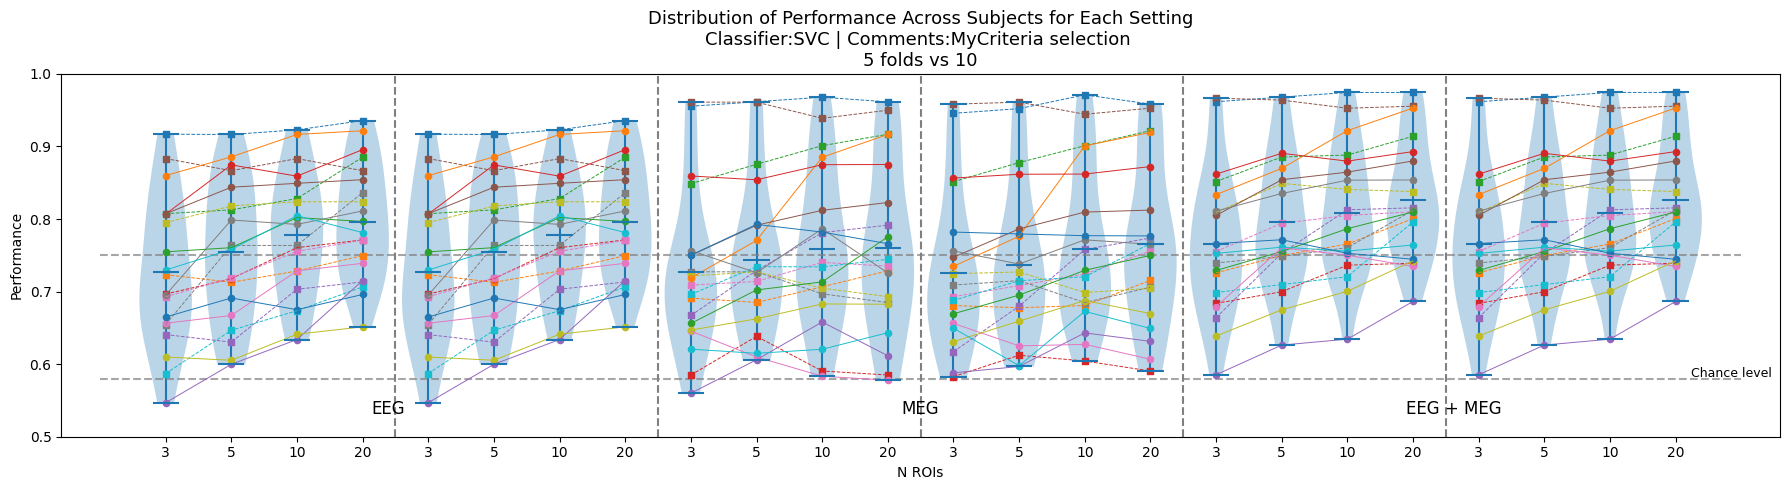

In [ ]:
# 10 folds vs 5 folds

import pandas as pd

PerData2 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl")
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerData["newcol"] = 1
PerData2["newcol"] = 2

combined = pd.concat([PerData, PerData2], ignore_index=True)


VisualizigNROIs=20
dict_fixed_selection = {"Classifier":"SVC", "Region Selection":"MyCriteria selection"}
divisioni = [0,4,8,12, 16,20,24]
VisualizigNROIs=[3,5,10,20]
Datatypes = ["EEG"]* len(VisualizigNROIs)*2 + ["MEG"]* len(VisualizigNROIs)*2 + ["EEG concat MEG"]* len(VisualizigNROIs)*2

VisualizigNROIs=VisualizigNROIs*6 # 3 is Datatype, 2 is PerData e PerData2

newcol=[1]*12 + [2]*12
dict_per_setting = {"NROIs":VisualizigNROIs, "DataType":Datatypes, "newcol":newcol}

x_ticklabels=[_ for _ in VisualizigNROIs]
textes = ["EEG", "MEG", "EEG + MEG"]
textes_x_positions = [.19,.5,.81, ]

plot_violin_all_subj(combined,  24,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions,
                  divisioni, xlabel="N ROIs", hlines_positions=[0.75],
                  track_subjects=True,  savepath=False, figsize=(18,5), additional_title="\n5 folds vs 10")

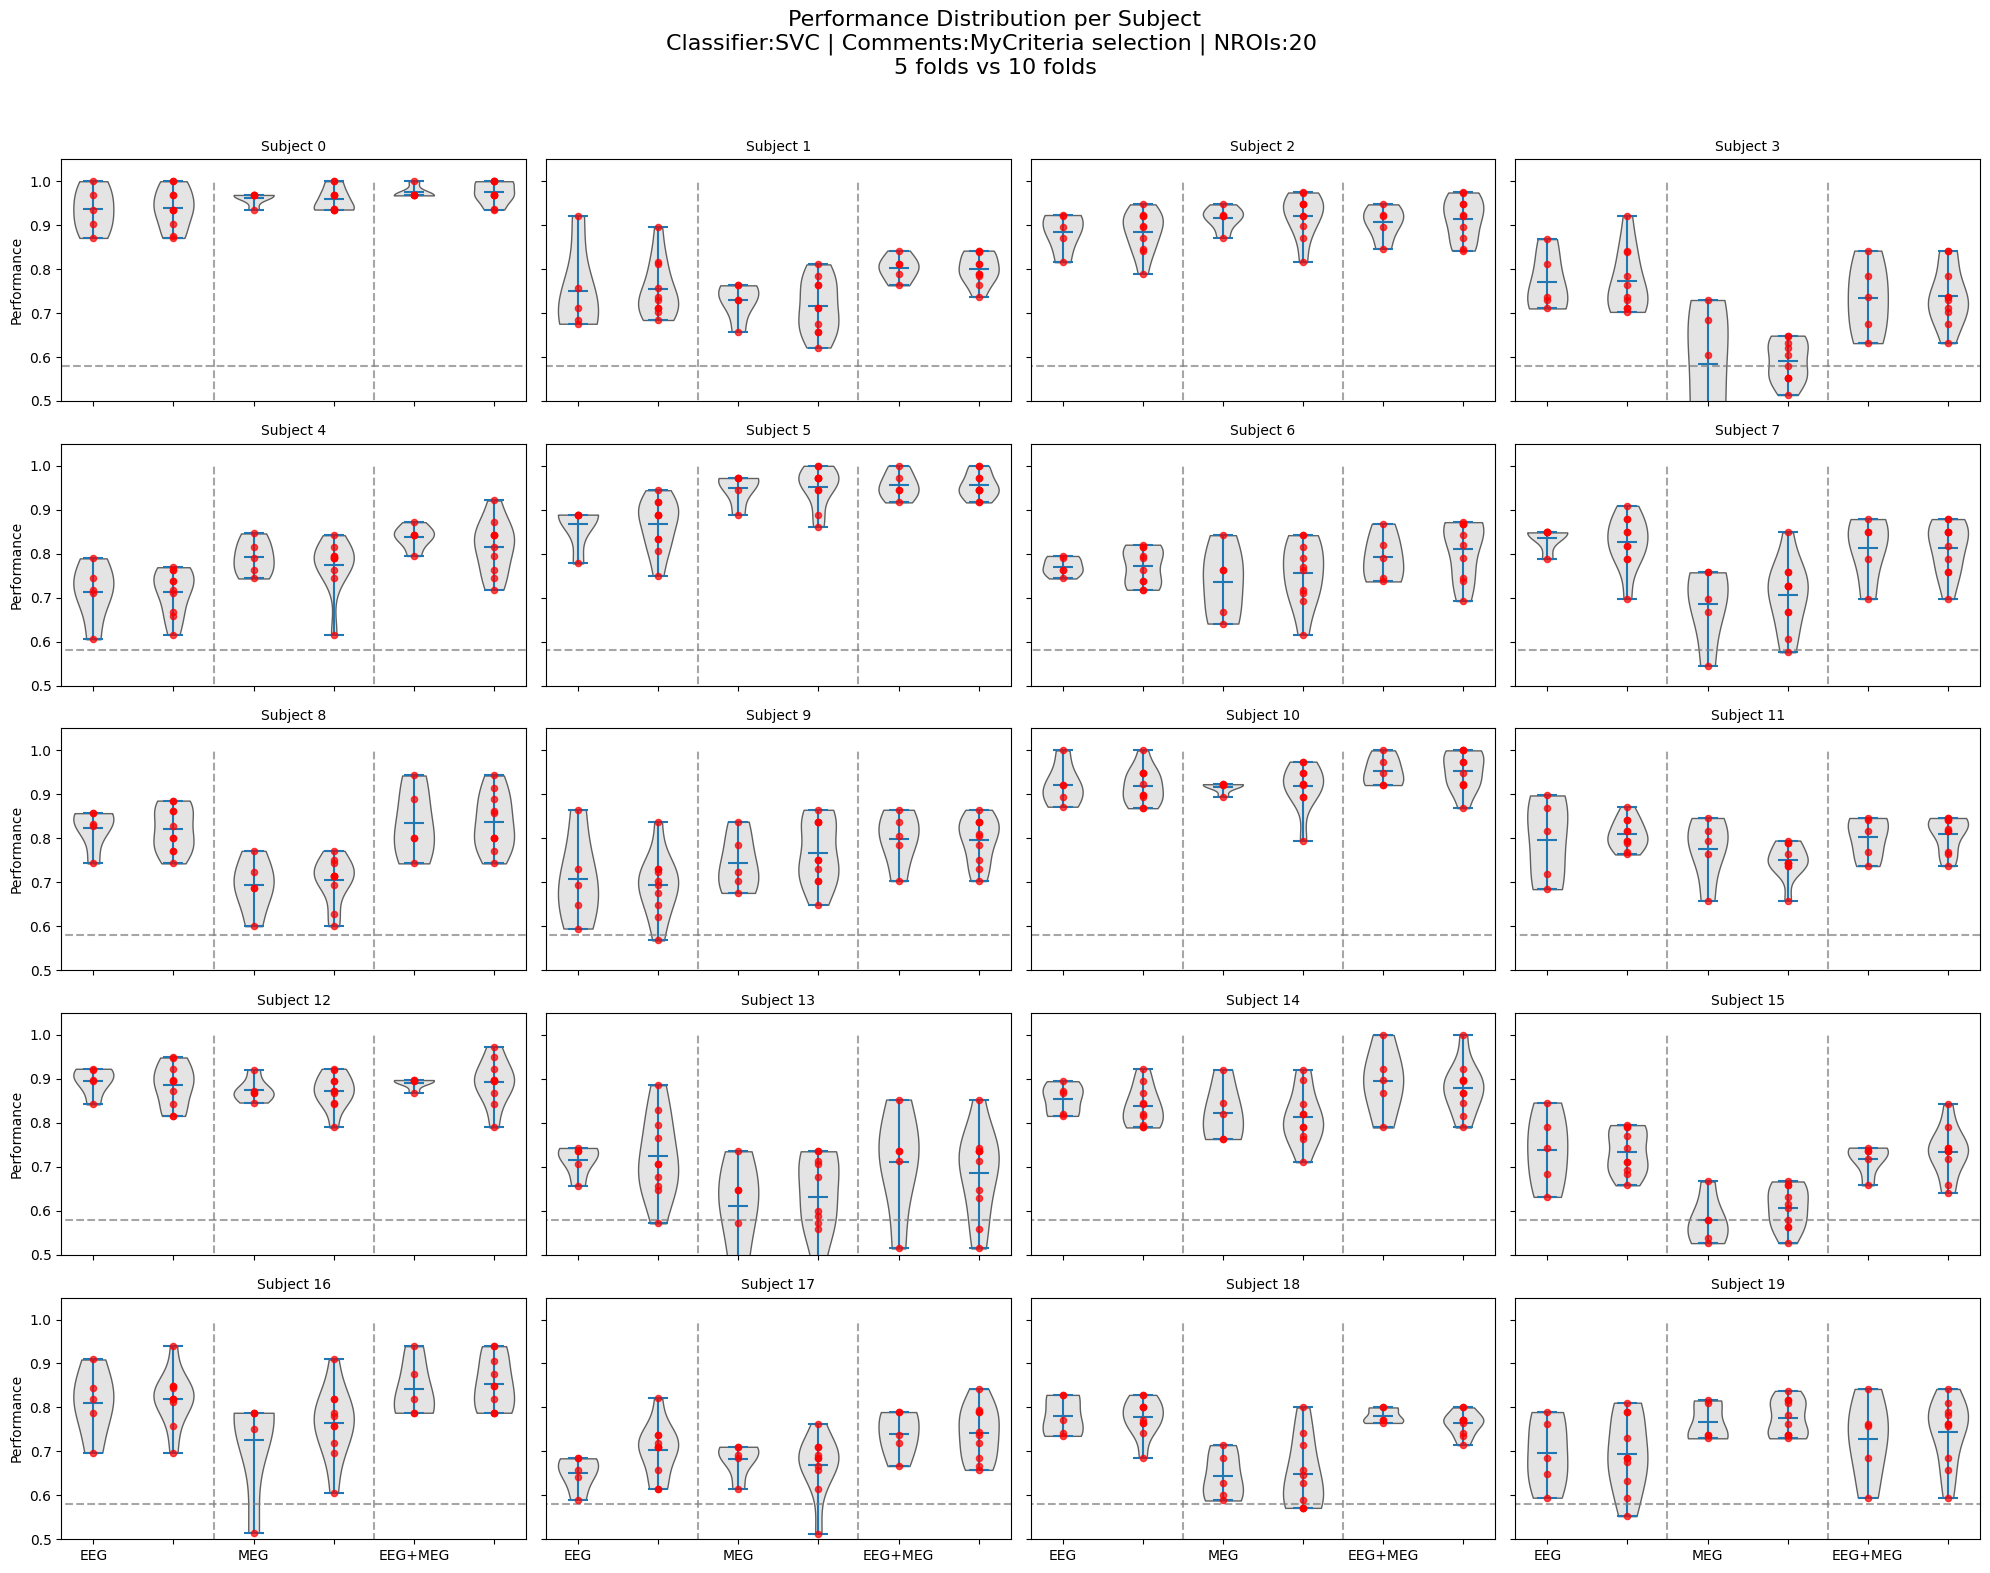

In [ ]:
import pandas as pd
PerformanceData5 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerformanceData10 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl")
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold
PerformanceData5["newcol"] = 5
PerformanceData10["newcol"] = 10

newcol = [5,10]*3
concate = pd.concat([PerformanceData5,PerformanceData10], ignore_index=True)

num_settings_showed_per_subject = 6
dict_fixed_selection = {
    "Classifier": "SVC",
    "Region Selection": "MyCriteria selection",
    "NROIs": 20,
}
Datatypes = ["EEG", "EEG", "MEG","MEG", "EEG concat MEG","EEG concat MEG"]
dict_per_setting = {"DataType": Datatypes, "newcol":newcol}
x_ticklabels = ["EEG","", "MEG","", "EEG+MEG",""]
pfs = plot_violin_track_single_fold(concate, num_settings_showed_per_subject, dict_fixed_selection, dict_per_setting, 
                                    x_ticklabels, additional_title="\n5 folds vs 10 folds",vlines_positions=[1.5,3.5])

## Brain plots

### All subject - cumulative

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain, read_ranks_subect, sort_rank
from matplotlib.colors import LinearSegmentedColormap
import os

subjects_dir = 'C:\\Users\\Dell_i5\\mne_data\\MNE-sample-data' + "\\subjects"
os.environ["SUBJECTS_DIR"] = subjects_dir
print("SUBJECTS_DIR set to:", subjects_dir)

colors = {"EEG":"green","MEG":"blue"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]


for DataType in ["EEG","MEG"]: #["EEG","MEG"]:
    for N_best_ROIs in[5,10,20,30]:  #[5,10,20,30]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        for regione in range(68):
            how_many_times[regione] = 0
        num_subj_at_least_1_right, num_subj_at_least_1_left = (0,0)
        for subject in range(20):
            ranks_subject = read_ranks_subect("../Results/RegionSelection/" \
            f"Selected_regions_MultiTtest_on_mean_alpha_beta_{DataType}_among_5_folds_training_selected.pkl", subject, read_all_trials=True)[0]

            at_least_1_left, at_least_1_right = (0,0)
            for migiori_regioni in range(N_best_ROIs):
                regione_ora = ranks_subject[migiori_regioni]
                how_many_times[regione_ora] +=  1 
                # controllo se nel soggetto ha almeno 1 regione tra quelle importanti di destra o sinistra
                if regione_ora in Interesting_regions_left:
                    at_least_1_left = 1
                    #print(subject, regione_ora)
                if regione_ora in Interesting_regions_right:
                    at_least_1_right = 1

            num_subj_at_least_1_right += at_least_1_right
            num_subj_at_least_1_left += at_least_1_left

                

        crs = [cmap(_/max(how_many_times.values())) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs{N_best_ROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f" Most selected region \n is selected in\n {max(how_many_times.values())} subjects\n on 20 subjects total",
            position="upper_left",
            font_size=10,
            color="black",
        )

        my_brain.add_text(0,0.3,f" T test alpha beta crit\n {DataType}\n Num_best_ROIs={N_best_ROIs}",font_size=10,)
        my_brain.add_text(0.65,0.3,f"Num of subject with \nat least 1 region in\nleft important: {num_subj_at_least_1_left}\nright important: {num_subj_at_least_1_right}",font_size=8,)

        savepathIMG = "../Images/Brain/Region_selection_criteria/"
        #my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs_{N_best_ROIs}_Ttest_alpha_beta_criteria.png")



SUBJECTS_DIR set to: C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\

### Per subject

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain, read_ranks_subect, sort_rank
import os

subjects_dir = 'C:\\Users\\Dell_i5\\mne_data\\MNE-sample-data' + "\\subjects"
os.environ["SUBJECTS_DIR"] = subjects_dir
print("SUBJECTS_DIR set to:", subjects_dir)

filepath = "../Results/"
performances=pd.read_pickle(filepath+f"BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")


colors = {"EEG":"green","MEG":"blue"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

limiti = [3,5,10,20]
colors = {"EEG": ["#6a3d9a", "#d73027", "#f49943", "#ebff0c", "#ffffff"],
          "MEG": ["navy", "#1f78b4", "#06d1ff", "#06ff23", "#ffffff"]}
nomi = {"EEG": ["Viola     <", "Rosso    <", "Arancio<", "Giallo    <"],
        "MEG": ["Blu        <", "Azzurro <", "Celeste<", "Verde   <", "#ffffff"]}

for DataType in ["MEG"]: #["EEG","MEG"]:

    cmap = colors[DataType]
    cl = nomi[DataType]
    
    for subject in range(20):
        ranks_subject = read_ranks_subect("../Results/RegionSelection/" \
        f"Selected_regions_Cohen_effect_size_{DataType}_among_5_folds_training_selected_freq_8_30.pkl", subject, read_all_trials=True)[0]

        crs=[[1]*4 for i in range(68)] 
        for rnk, region in enumerate(ranks_subject[0:20]):
            levl = 0 if rnk < limiti[0] else 1 if rnk < limiti[1] else 2 if rnk < limiti[2] else 3 if rnk < limiti[3] else 4
            crs[region] = cmap[levl]
        #crs = [cmap(_/4) for _ in how_many_times.values()] #3,5,10,20


        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([_ for _ in range(68)],
                            brain_object_dict={"title":f"{DataType}_Subject_{subject}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        fixed_dict = {"DataType":DataType,"subject": subject, "Classifier":"SVC"}
        perf_subj = []
        perf_subj_global = np.mean(select_rows(performances, fixed_dict|{"Region Selection": "Global Selection - Cohen based"})["Accuracy"].values[0])
        for mm in limiti:
            
            perf_subj.append(np.mean(select_rows(performances, fixed_dict|{"NROIs":mm, "Region Selection": "Cohen's d effect size selection"})["Accuracy"].values[0]))
                    
        plotter.add_text(
            f"N ROIS vs Performance\nRegion selection - Per subject\n"+"\n".join([f"{limiti[i]} - {perf_subj[i]:.2f}" for i in range(len(perf_subj))]),
            position="upper_left", font_size=10, color="black",
        )

        plotter.add_text(
            f"N ROIS & Performance\nRegion selection - Global\n"+ f"\n10 - {perf_subj_global:.2f}", 
            position="upper_right", font_size=10, color="black",
        )

        my_brain.add_text(0,0.15,f"Subject {subject}\n{DataType}",font_size=10)
        my_brain.add_text(0.7,0.1,f"Colori:\n  {cl[0]} 3\n  {cl[1]} 5\n  {cl[2]} 10\n  {cl[3]} 20",font_size=10)
        # my_brain.add_text(0.65,0.3,f"Num of subject with \nat least 1 region in\nleft important: {num_subj_at_least_1_left}\nright important: {num_subj_at_least_1_right}",font_size=8,)

        savepathIMG = "../Images/Brain/Region_selection_criteria/Single_Subjects/"
        my_brain.save_image(savepathIMG+f"Brain_{DataType}_Subjet_{subject}_Cohen_all_trials.png")



SUBJECTS_DIR set to: C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects
Reading labels from parcellation...


   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 label

In [ ]:
import pandas as pd
filepath = "../Results/"
performances=pd.read_pickle(filepath+f"BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

In [ ]:
from BCI_Library import  select_rows
fixed_dict = {"DataType":"EEG","subject": 2, "Classifier":"SVC", "Region Selection": "Global Selection - Cohen based"}
select_rows(performances, fixed_dict)

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
4502,"[14, 20, 32, 33, 44, 46, 48, 50, 58, 62]",10.0,EEG,"((8, 12), (12, 30))",2.0,SVC,"[0.8461538461538461, 0.9487179487179487, 0.947...",PowerSpectra - MeanMax band,Global Selection - Cohen based,2026-01-09,False


In [ ]:
performances

## Deep Learning

Text(0.5, 1.0, 'EEG\nsubj (1 - 2 - 8) = (peggio - meglio - intermedio)')

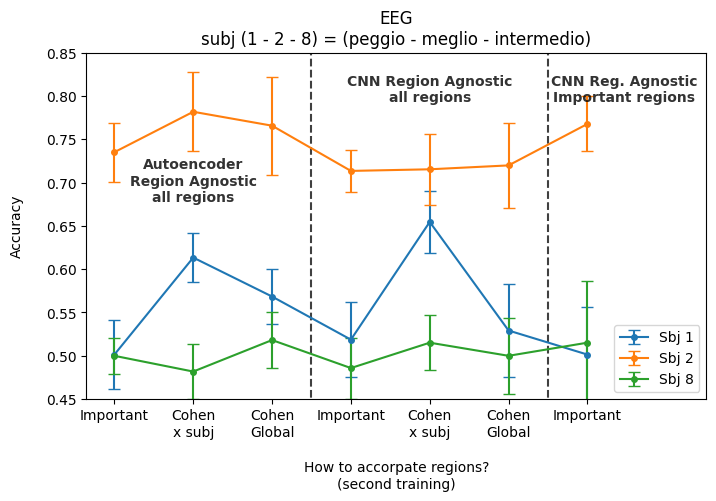

In [100]:
import numpy as np
import pandas as pd 
from BCI_Library import select_rows
import matplotlib.pyplot as plt

PerData1  = pd.read_pickle("../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_1.pkl")
PerData2  = pd.read_pickle("../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_2.pkl")
PerData8  = pd.read_pickle("../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_8.pkl")

DataType = "EEG"

dict_fixed_selection = {"Classifier": "SVC", "DataType": DataType}


lista_selezione_regioni_per_soggetto = ['Yes Important Regions - all',"Cohen's d effect size selection", 'Global Selection - Cohen based']*2+\
    ['Yes Important Regions - all']

lista_modelli_sbj_1 = ['2026-02-05-18_19_24_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 1']*3+\
['2026-02-05-18_19_43_CNN_1region_region_agnostic_First_Try Subject addestramento 1']*3+\
['2026-02-05-18_55_32_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 1']

lista_modelli_sbj_2 = ['2026-01-30-18_41_52_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 2']*3+\
['2026-01-31-13_19_18_CNN_1region_region_agnostic_input_reshaped_First_Try Subject addestramento 2']*3+\
['2026-02-02-15_59_15_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 2']


lista_modelli_sbj_8 = ['2026-02-05-17_17_40_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 8']*3+\
['2026-02-05-17_38_20_CNN_1region_region_agnostic_First_Try Subject addestramento 8']*3+\
['2026-02-05-18_00_56_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 8']

lista_modelli ={1:lista_modelli_sbj_1, 2:lista_modelli_sbj_2, 8:lista_modelli_sbj_8}


combined = pd.concat((PerData2, PerData1, PerData8))
plt.figure(figsize=(8,4.5))
accuracies = {}
stds = {}
for subject in [1,2,8]:
    accuracies[subject] = []
    stds[subject] = []
    for regione_selezione,commento in zip(lista_selezione_regioni_per_soggetto,lista_modelli[subject]):
        rows = select_rows(combined, dict_fixed_selection|{"Region Selection":regione_selezione, "Comments":commento})
        accuracies[subject].append(rows.Accuracy.apply(np.mean).values[0])
        stds[subject].append(rows.Accuracy.apply(np.std).values[0])
    plt.errorbar(range(len(accuracies[subject])),accuracies[subject],yerr=stds[subject],label=f"Sbj {subject}", marker=".", markersize=8, capsize=4)

ylim = (0.45, 0.85)
plt.vlines([2.5,5.5],0.35,0.9, linestyles="--", color="black", alpha=0.75)
plt.ylim(*ylim)
plt.legend(loc="lower right")
xticks = ["Important", "Cohen\nx subj", "Cohen\nGlobal"]*2+["Important"]
plt.xticks(ticks=range(len(lista_selezione_regioni_per_soggetto)), labels=xticks)
plt.xlabel("\nHow to accorpate regions?\n(second training)")
plt.ylabel("Accuracy\n")

plt.plot([7.15],[0.7])
testi=["Autoencoder\nRegion Agnostic\nall regions","CNN Region Agnostic\nall regions","CNN Reg. Agnostic\nImportant regions"]
xposizioni = [1,4,6.47]
yposs = [0.675,0.79,0.79]
for testo, xposizione, ypos in zip(testi, xposizioni, yposs):
    plt.text(xposizione, ypos, testo, va="bottom", ha="center", fontweight='bold', alpha=0.8)

plt.title(f"{DataType}\nsubj (1 - 2 - 8) = (peggio - meglio - intermedio)")

Text(0.5, 1.0, 'MEG\nsubj (1 - 2 - 8) = (peggio - meglio - intermedio)')

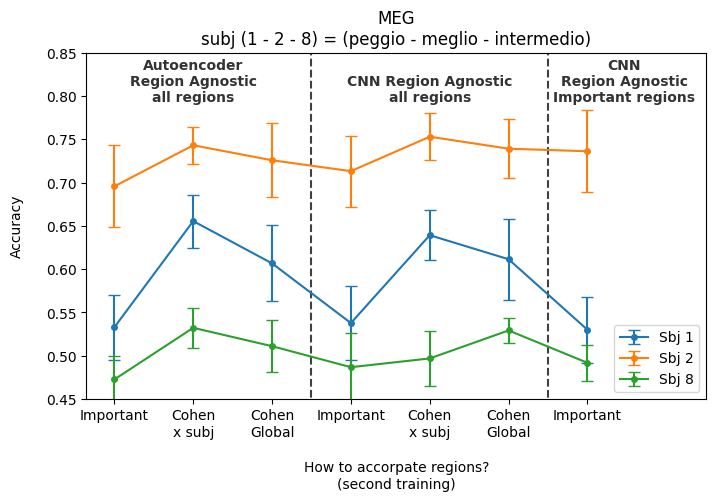

In [ ]:
import numpy as np
import pandas as pd 
from BCI_Library import select_rows
import matplotlib.pyplot as plt

PerData1  = pd.read_pickle("../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_1.pkl")
PerData2  = pd.read_pickle("../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_2.pkl")
PerData8  = pd.read_pickle("../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_8.pkl")

DataType = "MEG"

dict_fixed_selection = {"Classifier": "SVC", "DataType": DataType}


lista_selezione_regioni_per_soggetto = ['Yes Important Regions - all',"Cohen's d effect size selection", 'Global Selection - Cohen based']*2+\
    ['Yes Important Regions - all']

lista_modelli_sbj_1 = ['2026-02-11-12_22_26_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 1']*3+\
['2026-02-11-12_21_37_CNN_1region_region_agnostic_First_Try Subject addestramento 1']*3+\
['2026-02-11-14_17_59_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 1']

lista_modelli_sbj_2 = ['2026-02-11-11_25_57_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 2']*3+\
['2026-02-11-11_36_10_CNN_1region_region_agnostic_First_Try Subject addestramento 2']*3+\
['2026-02-11-14_18_38_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 2']


lista_modelli_sbj_8 = ['2026-02-11-12_53_26_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 8']*3+\
['2026-02-11-12_52_59_CNN_1region_region_agnostic_First_Try Subject addestramento 8']*3+\
['2026-02-11-17_17_14_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 8']

lista_modelli ={1:lista_modelli_sbj_1, 2:lista_modelli_sbj_2, 8:lista_modelli_sbj_8}


combined = pd.concat((PerData2, PerData1, PerData8))
plt.figure(figsize=(8,4.5))
accuracies = {}
stds = {}
for subject in [1,2,8]:
    accuracies[subject] = []
    stds[subject] = []
    for regione_selezione,commento in zip(lista_selezione_regioni_per_soggetto,lista_modelli[subject]):
        rows = select_rows(combined, dict_fixed_selection|{"Region Selection":regione_selezione, "Comments":commento})
        accuracies[subject].append(rows.Accuracy.apply(np.mean).values[0])
        stds[subject].append(rows.Accuracy.apply(np.std).values[0])
    plt.errorbar(range(len(accuracies[subject])),accuracies[subject],yerr=stds[subject],label=f"Sbj {subject}", marker=".", markersize=8, capsize=4)

ylim = (0.45, 0.85)
plt.vlines([2.5,5.5],0.35,0.9, linestyles="--", color="black", alpha=0.75)
plt.ylim(*ylim)
plt.legend(loc="lower right")
xticks = ["Important", "Cohen\nx subj", "Cohen\nGlobal"]*2+["Important"]
plt.xticks(ticks=range(len(lista_selezione_regioni_per_soggetto)), labels=xticks)
plt.xlabel("\nHow to accorpate regions?\n(second training)")
plt.ylabel("Accuracy\n")

plt.plot([7.15],[0.7])
testi=["Autoencoder\nRegion Agnostic\nall regions","CNN Region Agnostic\nall regions","CNN\nRegion Agnostic\nImportant regions"]
xposizioni = [1,4,6.47]
yposs = [0.79, 0.79, 0.79]
for testo, xposizione, ypos in zip(testi, xposizioni, yposs):
    plt.text(xposizione, ypos, testo, va="bottom", ha="center", fontweight='bold', alpha=0.8)

plt.title(f"{DataType}\nsubj (1 - 2 - 8) = (peggio - meglio - intermedio)")

In [15]:
set(combined["Region Selection"].values)

{"Cohen's d effect size selection",
 'Global Selection - Cohen based',
 'Yes Important Regions - all'}

In [4]:
lista_selezione_regioni_per_soggetto = ['Yes Important Regions - all',"Cohen's d effect size selection", 'Global Selection - Cohen based']*2+\
    ['Yes Important Regions - all']
lista_selezione_regioni_per_soggetto

['Yes Important Regions - all',
 "Cohen's d effect size selection",
 'Global Selection - Cohen based',
 'Yes Important Regions - all',
 "Cohen's d effect size selection",
 'Global Selection - Cohen based',
 'Yes Important Regions - all']

In [ ]:
lista_modelli_sbj_1 = ['2026-02-05-18_19_24_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 1']*3+\
['2026-02-05-18_19_43_CNN_1region_region_agnostic_First_Try Subject addestramento 1']*3+\
['2026-02-05-18_55_32_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 1']

lista_modelli_sbj_2 = ['2026-01-30-18_41_52_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 2']*3+\
['2026-01-31-13_19_18_CNN_1region_region_agnostic_input_reshaped_First_Try Subject addestramento 2']*3+\
['2026-02-02-15_59_15_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 2']


lista_modelli_sbj_8 = ['2026-02-05-17_17_40_Autoencoder_1region_region_agnostic_First_Try Subject addestramento 8']*3+\
['2026-02-05-17_38_20_CNN_1region_region_agnostic_First_Try Subject addestramento 8']*3+\
['2026-02-05-18_00_56_CNN_1region_region_agnostic_Training_on_Interesting_Regions Subject addestramento 8']

lista_modelli ={1:lista_modelli_sbj_1, 2:lista_modelli_sbj_2, 8:lista_modelli_sbj_8}

## Verify Deep Learning


In [6]:
import numpy as np
import pandas as pd 
from BCI_Library import select_rows
import matplotlib.pyplot as plt
subj = 8
DataType = "EEG"
Classifier = "SVC"
model = "2026-03-06-10_20_58_Autoencoder_1region_region_agnostic_EEG_to_MEG"

Region_Selection = "Cohen's d effect size selection"
model = model + f" Subject addestramento {subj}"

dict_selection = { "DataType": DataType, "Region Selection": Region_Selection, "Features":"CNN_extracted"}
PerData_deep  = pd.read_pickle(f"../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_{subj}.pkl")

for perfa in select_rows(PerData_deep, dict_selection).Accuracy.apply(np.mean).values:
   print(f"{perfa:.3f}")

0.527
0.515
0.533


In [7]:
select_rows(PerData_deep, dict_selection)

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Accuracy,Features,Region Selection,Date,Personalized_Freq_Range,Comments
9,"[50, 26, 27, 34, 20, 51, 12, 15]",8.0,EEG,-,8.0,LDA,"[0.4898989898989899, 0.5202020202020202, 0.535...",CNN_extracted,Cohen's d effect size selection,2026-02-06,-,2026-02-05-17_38_20_CNN_1region_region_agnosti...
10,"[50, 26, 27, 34, 20, 51, 12, 15]",8.0,EEG,-,8.0,SVC,"[0.47474747474747475, 0.48484848484848486, 0.5...",CNN_extracted,Cohen's d effect size selection,2026-02-06,-,2026-02-05-17_38_20_CNN_1region_region_agnosti...
11,"[50, 26, 27, 34, 20, 51, 12, 15]",8.0,EEG,-,8.0,RandomForest,"[0.5151515151515151, 0.5202020202020202, 0.565...",CNN_extracted,Cohen's d effect size selection,2026-02-06,-,2026-02-05-17_38_20_CNN_1region_region_agnosti...


## Deep vs Previous

2026-04-21 17:40:52.979526: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 17:40:53.039103: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-21 17:40:54.204429: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


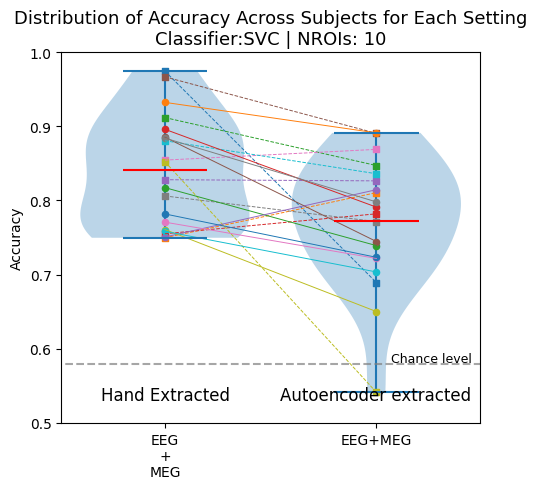

(0.4, 1.0)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
savepathIMG = "../Images/"
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold, select_rows

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerData_deep = pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN.pkl")

dict_fixed_selection = {"Classifier":"SVC"}

Datatypes = ["EEG concat MEG", "EEG+MEG"]
reg_sel = "Cohen's d effect size selection"  #"Cohen's d effect size selection spectra starting from 3s"
NROIs = 10

dict_setting_classic = {"DataType":Datatypes[0], "Region Selection":reg_sel, "NROIs":NROIs, "Classifier":"SVC"}
rows_classic = select_rows(PerData, dict_setting_classic)

combined = pd.concat([rows_classic, PerData_deep], ignore_index=True)

features = ['PowerSpectra - MeanMax band','Autoencoder_extracted']

divisioni = [0,2]
x_ticklabels = [_.replace(" concat ","\n+\n") for _ in Datatypes]
textes = ["Hand Extracted", "Autoencoder extracted"]
textes_x_positions = [.25, .75]

fig, ax = plot_violin_all_subj(combined,  2,  dict_fixed_selection,  {"Features": features},
                  x_ticklabels,  textes,  textes_x_positions, 
                  divisioni, hlines_positions=[],
                  track_subjects=True,  savepath=False,
                  additional_title="| NROIs: 10", figsize=(5,5))
ax.set_ylim(0.4,1)


In [10]:
rows_classic.Accuracy.apply(np.mean).to_excel("../Results/BCI_Performances/Classic_Performances.xlsx", index=False)
PerData_deep.Accuracy.apply(np.mean).to_excel("../Results/BCI_Performances/Classic_Deep_Performances.xlsx", index=False)


In [9]:
import numpy as np
rows_classic.Accuracy.apply(np.mean).to_excel("../Results/BCI_Performances/Classic_Performances.xlsx", index=False)

In [16]:
set(combined.Features)

{'Autoencoder_extracted', 'PowerSpectra - MeanMax band'}

In [6]:
import pandas as pd
savepathIMG = "../Images/"
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold, select_rows

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerData_deep = pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN.pkl")

dict_fixed_selection = {"Classifier":"SVC"}

Datatypes = "EEG concat MEG"
reg_sel = "Cohen's d effect size selection"  #"Cohen's d effect size selection spectra starting from 3s"
NROIs = 10


dict_setting_classic = {"DataType":Datatypes, "Region Selection":reg_sel, "NROIs":NROIs}
rows_classic = select_rows(PerData, dict_setting_classic)

In [2]:
import pandas as pd

PerData_deep = pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN.pkl")

## Deep Cross Subject

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cross_performance = pd.read_pickle("../Results/BCI_Performances/DNN/BCI_Performances_DNN_cross_2_subjects.pkl")

sbj_secnd_train = cross_performance.subject.values
sbj_secnd_trains = []
for _ in range(len(sbj_secnd_train)):
    sbj_secnd_trains.append(int(sbj_secnd_train[_]))

sbj_donors = []
for train_details in cross_performance.Comments.str.split(" "):
    sbj_donors.append(int(train_details[-1]))

accuracies = []
for list_accuracy in  cross_performance.Accuracy:
    accuracies.append(np.mean(list_accuracy))


In [2]:
import numpy as np

# Example inputs
donor = np.array(sbj_donors)
second_training = np.array(sbj_secnd_trains)
accuracy = np.array(accuracies)

# Initialize matrix with NaNs
matrix = np.full((20, 20), np.nan)

# Fill matrix
for d, s, a in zip(donor, second_training, accuracy):
    matrix[d, s] = a


row_means = np.nanmean(matrix, axis=1)   # mean per donor
col_means = np.nanmean(matrix, axis=0)   # mean per second_training


extended = np.full((21, 21), np.nan)

# Original data
extended[:20, :20] = matrix

# Add means
extended[:20, 20] = row_means     # last column
extended[20, :20] = col_means     # last row


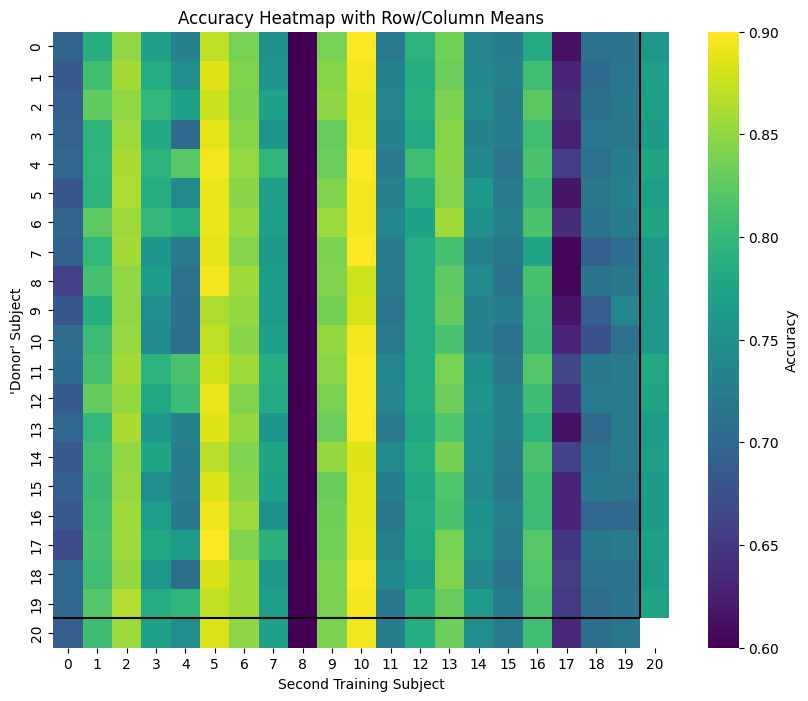

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    extended,
    cmap="viridis",
    vmin=0.6, vmax=0.9,
    square=True,
    cbar_kws={'label': 'Accuracy'}
)

plt.xlabel("Second Training Subject")
plt.ylabel("'Donor' Subject")
plt.title("Accuracy Heatmap with Row/Column Means")
plt.hlines([20],0,20, color="black")
plt.vlines([20],0,20, color="black")
plt.show()

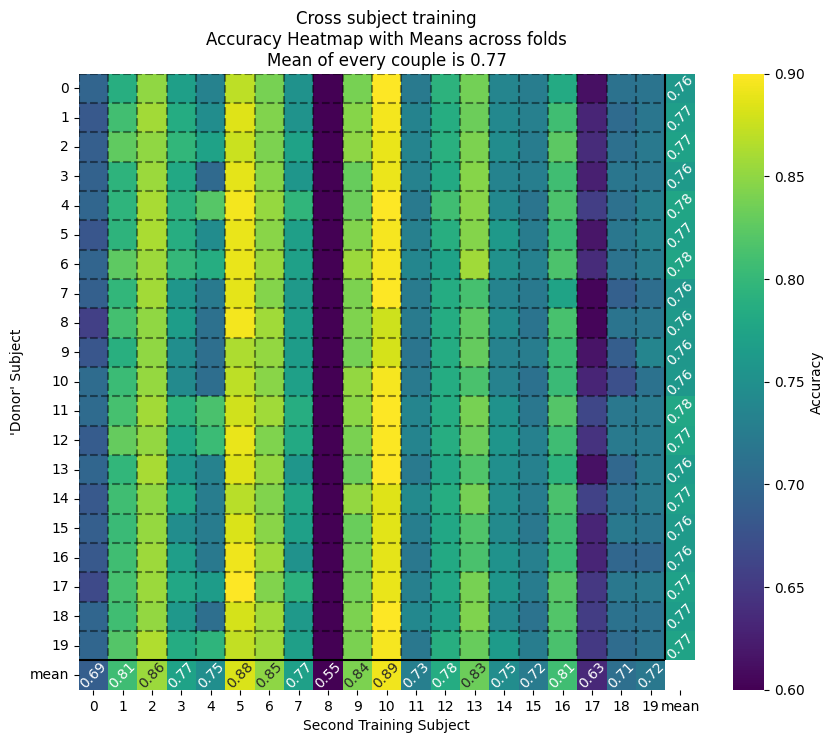

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Create annotation matrix (same shape, but empty strings)
annot = np.full(extended.shape, "", dtype=object)

# Fill only last column (row means)
for i in range(20):
    if not np.isnan(extended[i, 20]):
        annot[i, 20] = f"{extended[i, 20]:.2f}"

# Fill only last row (column means)
for j in range(20):
    if not np.isnan(extended[20, j]):
        annot[20, j] = f"{extended[20, j]:.2f}"

# (optional) bottom-right corner (mean of means if exists)
if not np.isnan(extended[20, 20]):
    annot[20, 20] = f"{extended[20, 20]:.2f}"

ax = sns.heatmap(
    extended,
    cmap="viridis",
    vmin=0.6, vmax=0.9,
    square=True,
    annot=annot,
    fmt="",
    cbar_kws={'label': 'Accuracy'}
)

for text in ax.texts:
    if text.get_text() != "":
        text.set_rotation(45)   # try 30, 45, 60, etc.

plt.hlines([20],0,20, color="black")
plt.vlines([20],0,20, color="black")


plt.hlines([i for i in range(20)],0,20, color="black", linestyle="--", alpha=0.45)
plt.vlines([i for i in range(20)],0,20, color="black", linestyle="--", alpha=0.45)

labels = list(range(20)) + ["mean"]
plt.xticks(ticks=np.arange(21) + 0.5, labels=labels, rotation=0)
plt.yticks(ticks=np.arange(21) + 0.5, labels=labels, rotation=0)

plt.xlabel("Second Training Subject")
plt.ylabel("'Donor' Subject")
plt.title(f"Cross subject training\nAccuracy Heatmap with Means across folds\nMean of every couple is {extended[20][:-1].mean():.2f}")

plt.show()

np.float64(0.7670993313553492)

# Undefined but important

In [110]:
import pandas as pd
Normal_sampled = pd.read_pickle("../_Deep_Learning/Models_trained/Subject_2/EEG/Autoencoders/"+
"2026-01-30-18_41_52_Autoencoder_1region_region_agnostic_First_Try/aggregated_region_performance.pkl")

Up_sampled = pd.read_pickle("../_Deep_Learning/Models_trained/Subject_2/EEG/Autoencoders/"+
"2026-02-03-15_19_11_Autoencoder_1region_region_agnostic_upsampled_signals/aggregated_region_performance.pkl")

In [111]:
Up_sampled.head()

,region,NROIs,n_windows,MSE_mean,MSE_std,MAE_mean,MAE_std,Split_seed,DataType,subject,Features,Comments,Date,WindowsNormalization
0,1.0,1,"(220, 220, 209, 209, 209)","(0.40688109407067813, 0.4005910374111211, 0.37...","(0.12888048435310565, 0.10510328427008324, 0.1...","(0.5054146758027291, 0.503514177599747, 0.4867...","(0.08584865455805842, 0.06686112257109125, 0.0...",224,EEG,2,Autoencoder_extracted,Upsampling 2x input,2026-02-03,RegionWise
1,2.0,1,"(220, 220, 209, 209, 209)","(0.3469108255871423, 0.28013054386615605, 0.27...","(0.2596684811529355, 0.10000480319758631, 0.08...","(0.45107948507226253, 0.41502962913888813, 0.4...","(0.13451774197119495, 0.06867449861649451, 0.0...",224,EEG,2,Autoencoder_extracted,Upsampling 2x input,2026-02-03,RegionWise
2,3.0,1,"(220, 220, 209, 209, 209)","(0.26027702032377015, 0.25120709590841006, 0.2...","(0.10540680750460792, 0.1029809407380391, 0.10...","(0.3977853498808809, 0.39091593006602415, 0.39...","(0.08367888096726933, 0.08085537574813892, 0.0...",224,EEG,2,Autoencoder_extracted,Upsampling 2x input,2026-02-03,RegionWise
3,4.0,1,"(220, 220, 209, 209, 209)","(0.2349253225434876, 0.24015292123527535, 0.21...","(0.09576556105445307, 0.09476545039482522, 0.0...","(0.3810199366815916, 0.38477055256401166, 0.36...","(0.08091708445956586, 0.07576329088252444, 0.0...",224,EEG,2,Autoencoder_extracted,Upsampling 2x input,2026-02-03,RegionWise
4,5.0,1,"(220, 220, 209, 209, 209)","(0.24538645537431406, 0.25216497264284504, 0.2...","(0.10602611413771267, 0.119671931291896, 0.099...","(0.387633804625342, 0.392426799345505, 0.36551...","(0.08069064485260674, 0.08847961332542639, 0.0...",224,EEG,2,Autoencoder_extracted,Upsampling 2x input,2026-02-03,RegionWise


Text(0, 0.5, 'Mean Squared Error')

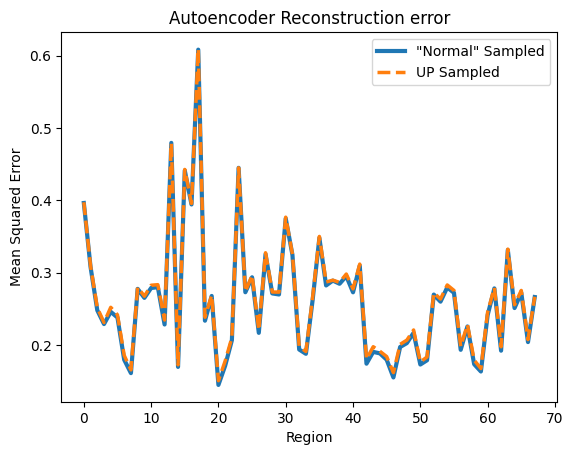

In [138]:
plt.plot(Normal_sampled["MSE_mean"].apply(np.mean),linewidth=3, label = '"Normal" Sampled')
plt.plot(Up_sampled["MSE_mean"].apply(np.mean),linestyle="--",linewidth=2.5, label = "UP Sampled")
plt.legend()
plt.title("Autoencoder Reconstruction error")
plt.xlabel("Region")
plt.ylabel("Mean Squared Error")

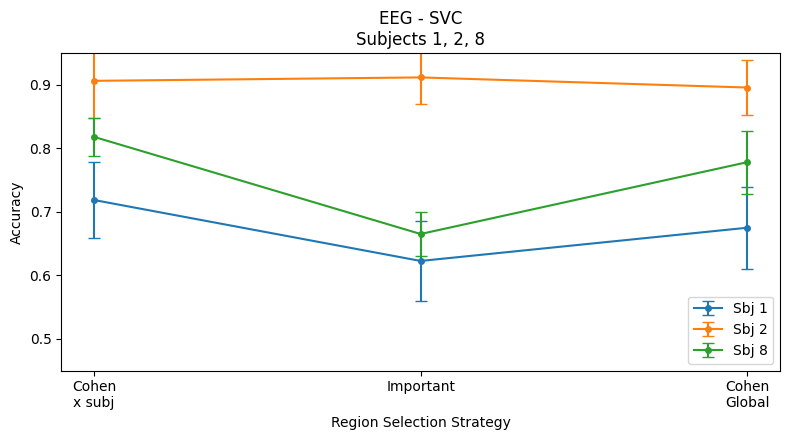

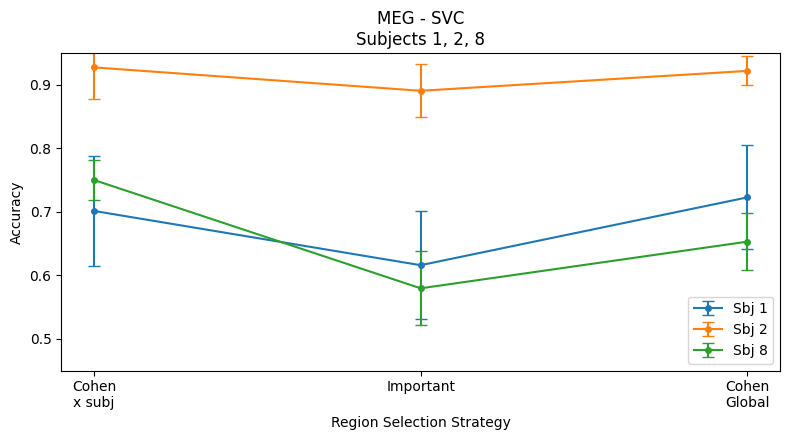

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from BCI_Library import select_rows

for DataType in ["EEG", "MEG"]:
    subjects = [1, 2, 8]

    region_selections = [
        "Cohen's d effect size selection",
        "Yes Important Regions - all",
        "Global Selection - Cohen based"]

    Classifier = "SVC"

    plt.figure(figsize=(8, 4.5))

    accuracies = {}
    stds = {}

    for subject in subjects:

        accuracies[subject] = []
        stds[subject] = []

        for region_sel in region_selections:

            # Rule for NROIs
            if region_sel in [
                "Cohen's d effect size selection",
                "Global Selection - Cohen based"
            ]:
                nrois = 10
            else:
                nrois = 8

            selection_dict = {
                "subject": subject,
                "Region Selection": region_sel,
                "DataType": DataType,
                "Classifier": Classifier,
                "NROIs": nrois
            }

            rows = select_rows(performances, selection_dict)
            mean_acc = rows.Accuracy.apply(np.mean).values[0]
            std_acc = rows.Accuracy.apply(np.std).values[0]

            accuracies[subject].append(mean_acc)
            stds[subject].append(std_acc)

        plt.errorbar(
            range(len(region_selections)),
            accuracies[subject],
            yerr=stds[subject],
            label=f"Sbj {subject}",
            marker=".",
            markersize=8,
            capsize=4
        )


    plt.xticks(
        ticks=range(len(region_selections)),
        labels=["Cohen\nx subj", "Important", "Cohen\nGlobal"]
    )

    plt.xlabel("Region Selection Strategy")
    plt.ylabel("Accuracy")
    plt.ylim(0.45, 0.95)
    plt.legend(loc="lower right")

    plt.title(f"{DataType} - SVC\nSubjects 1, 2, 8")

    plt.tight_layout()
    plt.show()


In [8]:
import pandas as pd
tutti_sub = [1,2,4,8,18]
PerData = {}
for sub in tutti_sub:
    PerData[sub] = pd.read_pickle(f"../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_{sub}.pkl")


In [13]:
import numpy as np
MySub = 2
for MySub in tutti_sub:
    MyPd = PerData[MySub]

    oibo = MyPd[(MyPd["Classifier"]=="SVC") * (MyPd["Features"]=="Autoencoder_extracted") * (MyPd["Region Selection"]=="Cohen's d effect size selection")]

    oibo.loc[:,["subject",]]

    df2 = (oibo[["subject", "Comments", "Accuracy"]].assign(
            Specifics=lambda d: (
                d["Comments"].str.split(" Subject").str[0]
                .str.replace(r"^\d{4}-\d{2}-\d{2}-\d{2}_\d{2}_\d{2}_Autoencoder_", "", regex=True)),
            Accuracy_mean=lambda d: d["Accuracy"].apply(
                lambda x: np.mean(ast.literal_eval(x)) if isinstance(x, str) else np.mean(x)))
        [["subject", "Specifics", "Accuracy_mean"]]
    )
    df2.to_excel(f"../Results/BCI_Performances/DNN/Summary_{MySub}.xlsx")